# The Real Brokerage Inc. (NASDAQ: REAX) — Financial Model

**Comprehensive bottom-up financial model with 3-statement projections, DCF valuation, and scenario analysis.**

Data sources: 2025 Form 40-F Financial Statements, Q4 2025 IR Presentation, StockAnalysis.com

In [1]:
# ============================================================
# CELL GROUP 1: SETUP & DATA INPUT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

# Color palette
COLORS = {
    'primary': '#1a73e8',
    'secondary': '#34a853',
    'accent': '#ea4335',
    'neutral': '#5f6368',
    'light': '#a8d5e2',
    'gold': '#f9ab00',
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# ── Annual Income Statement ($thousands) ─────────────────────
# 2023 data is summary-level; 2024-2025 from audited Form 40-F

income_stmt = pd.DataFrame({
    'Revenue':              [689_160, 1_264_639, 1_968_416],
    'COGS':                 [626_260, 1_149_898, 1_802_728],
    'Gross_Profit':         [ 62_900,   114_741,   165_688],
    'GA_Expense':           [ 35_000,    61_084,    74_359],  # 2023 est
    'Marketing_Expense':    [ 30_000,    57_477,    82_383],  # 2023 est
    'RD_Expense':           [  7_000,    12_156,    17_443],  # 2023 est
    'Settlement':           [      0,     9_250,       750],
    'Total_OpEx':           [ 72_000,   139_967,   174_935],
    'Operating_Income':     [ -9_100,   -25_226,    -9_247],
    'Other_Income':         [    300,       496,       995],
    'Finance_Expense':      [ -1_200,    -1_723,      -554],
    'Pretax_Income':        [-10_000,   -26_453,    -8_806],
    'Tax':                  [      0,         0,      -740],
    'Net_Income':           [-27_500,   -26_453,    -8_066],
    'SBC':                  [ 30_000,    52_916,    68_146],  # 2023 est
    'DA':                   [  1_000,     1_396,     1_929],  # 2023 est
    'Adj_EBITDA':           [ 13_900,    40_000,    62_900],
    'Shares_Diluted_K':     [175_000,   191_172,   219_873],  # 2023 est
}, index=[2023, 2024, 2025])
income_stmt.index.name = 'Year'

# Revenue by type ($thousands)
rev_by_type = pd.DataFrame({
    'Brokerage':   [680_000, 1_255_799, 1_956_483],
    'Title':       [  5_000,     4_788,     5_035],
    'Mortgage':    [  3_500,     4_010,     6_009],
    'Wallet':      [      0,        42,       889],
}, index=[2023, 2024, 2025])
rev_by_type.index.name = 'Year'

# Revenue by geography ($thousands)
rev_by_geo = pd.DataFrame({
    'United_States': [580_000, 1_109_616, 1_748_894],
    'Canada':        [109_160,   155_023,   219_522],
}, index=[2023, 2024, 2025])
rev_by_geo.index.name = 'Year'

print('Income Statement loaded.')
income_stmt[['Revenue', 'Gross_Profit', 'Net_Income', 'Adj_EBITDA']]

Income Statement loaded.


,Revenue,Gross_Profit,Net_Income,Adj_EBITDA
Year,,,,
2023,689160,62900,-27500,13900
2024,1264639,114741,-26453,40000
2025,1968416,165688,-8066,62900


In [3]:
# ── Expense Breakdown by Nature ($thousands, 2024-2025) ──────

ga_detail = pd.DataFrame({
    'Salaries_Benefits':  [27_081, 38_903],
    'SBC_Employees':      [ 9_324,  8_416],
    'Administrative':     [ 3_816,  3_155],
    'Professional_Fees':  [16_437, 18_337],
    'DA':                 [ 1_396,  1_929],
    'Other':              [ 3_030,  3_619],
}, index=[2024, 2025])

mktg_detail = pd.DataFrame({
    'Salaries_Benefits':  [ 1_048,  1_686],
    'SBC_Employees':      [    29,    160],
    'SBC_Agents':         [10_077, 14_727],
    'Revenue_Share':      [42_727, 60_520],
    'Other_Marketing':    [ 3_596,  5_290],
}, index=[2024, 2025])

rd_detail = pd.DataFrame({
    'Salaries_Benefits':  [6_400, 10_321],
    'SBC_Employees':      [  949,  1_158],
    'Software_Cloud':     [3_219,  5_793],
    'Other':              [1_588,    171],
}, index=[2024, 2025])

sbc_detail = pd.DataFrame({
    'COGS_Agent_Awards':    [32_537, 43_685],
    'Marketing_Agent':      [10_077, 14_727],
    'Marketing_FTE':        [    29,    160],
    'RD_FTE':               [   949,  1_158],
    'GA_FTE':               [ 9_324,  8_416],
    'Total_SBC':            [52_916, 68_146],
    'Of_which_Options':     [ 2_171,  1_019],
    'Of_which_RSUs':        [50_745, 67_127],
}, index=[2024, 2025])

print('Expense detail loaded.')
sbc_detail[['Total_SBC', 'Of_which_Options', 'Of_which_RSUs']]

Expense detail loaded.


,Total_SBC,Of_which_Options,Of_which_RSUs
2024,52916,2171,50745
2025,68146,1019,67127


In [4]:
# ── Balance Sheet ($thousands) ───────────────────────────────

balance_sheet = pd.DataFrame({
    # Assets
    'Cash':                    [23_376, 33_213],
    'Restricted_Cash':         [24_089, 26_338],
    'Investments':             [ 9_449, 16_731],
    'Trade_Receivables':       [14_235, 20_170],
    'ST_Financing_Recv':       [     0,  6_231],
    'Other_Current_Assets':    [ 1_762,  3_081],
    'Total_Current_Assets':    [72_911, 105_764],
    'Intangibles_Net':         [ 2_575,  4_157],
    'Goodwill':                [ 8_993,  8_993],
    'PPE_Net':                 [ 2_116,  2_455],
    'Equity_Securities':       [     0,  2_250],
    'LT_Financing_Recv':       [     0,  2_311],
    'Deferred_Tax_Asset':      [     0,    931],
    'Total_NonCurrent_Assets': [13_684, 21_097],
    'Total_Assets':            [86_595, 126_861],
    # Liabilities
    'Accounts_Payable':        [ 1_374,  1_161],
    'Accrued_Liabilities':     [25_939, 38_205],
    'Customer_Deposits':       [24_089, 26_338],
    'Other_Payables':          [ 3_050,  9_562],
    'Total_Current_Liab':      [54_452, 75_266],
    'Deferred_Tax_Liab':       [     0,     10],
    'Total_Liabilities':       [54_452, 75_276],
    # Equity
    'APIC':                    [138_639, 164_208],
    'Accumulated_Deficit':     [-104_746, -112_851],
    'AOCI':                    [    708,     318],
    'Treasury_Stock':          [ -2_455,       0],
    'Equity_Owners':           [ 32_146,  51_675],
    'NCI':                     [     -3,     -90],
    'Total_Equity':            [ 32_143,  51_585],
    'Total_Liab_Equity':       [ 86_595, 126_861],
}, index=[2024, 2025])
balance_sheet.index.name = 'Year'

# Verify balance sheet balances
for yr in [2024, 2025]:
    diff = balance_sheet.loc[yr, 'Total_Assets'] - balance_sheet.loc[yr, 'Total_Liab_Equity']
    print(f'{yr}: A={balance_sheet.loc[yr,"Total_Assets"]:,.0f}  L+E={balance_sheet.loc[yr,"Total_Liab_Equity"]:,.0f}  Diff={diff}')

balance_sheet[['Total_Assets', 'Total_Liabilities', 'Total_Equity']]

2024: A=86,595  L+E=86,595  Diff=0
2025: A=126,861  L+E=126,861  Diff=0


,Total_Assets,Total_Liabilities,Total_Equity
Year,,,
2024,86595,54452,32143
2025,126861,75276,51585


In [5]:
# ── Cash Flow Statement ($thousands) ─────────────────────────

cash_flow = pd.DataFrame({
    'Net_Income':              [-26_453,  -8_066],
    'DA':                      [  1_396,   1_929],
    'SBC':                     [ 52_916,  68_146],
    'Finance_Costs':           [    376,    -180],
    'FV_Warrants':             [    600,       0],
    'Deferred_Tax':            [      0,    -921],
    'Chg_Trade_Recv':          [ -7_794,  -5_935],
    'Chg_Financing_Recv':      [      0,  -8_542],
    'Chg_Other_CA':            [    433,  -1_319],
    'Chg_AP':                  [    803,    -213],
    'Chg_Accrued_Liab':        [ 12_565,  12_266],
    'Chg_Customer_Deposits':   [ 11_141,   2_249],
    'Chg_Other_Payables':      [  2_748,   6_512],
    'CFO':                     [ 48_731,  65_926],
    # Investing
    'Purchase_Equity_Sec':     [      0,  -2_250],
    'Capex':                   [ -1_045,  -1_100],
    'Purchase_Intangibles':    [      0,  -2_750],
    'Purchase_Financial':      [ -1_692, -16_053],
    'Proceeds_Financial':      [  6_546,   8_559],
    'CFI':                     [  3_809, -13_594],
    # Financing
    'Share_Repurchase':        [-36_283, -39_363],
    'Tax_SBC':                 [ -2_832,  -2_928],
    'Option_Proceeds':         [  6_275,   2_169],
    'NCI_Distributions':       [   -300,    -126],
    'CFF':                     [-33_140, -40_248],
    # Summary
    'Net_Change_Cash':         [ 19_400,  12_084],
    'Cash_Begin':              [ 27_655,  47_465],
    'FX_Effect':               [    410,       2],
    'Cash_End':                [ 47_465,  59_551],
}, index=[2024, 2025])
cash_flow.index.name = 'Year'

# Verify cash reconciliation
for yr in [2024, 2025]:
    calc = cash_flow.loc[yr, 'Cash_Begin'] + cash_flow.loc[yr, 'Net_Change_Cash'] + cash_flow.loc[yr, 'FX_Effect']
    print(f'{yr}: Begin {cash_flow.loc[yr,"Cash_Begin"]:,.0f} + Net {cash_flow.loc[yr,"Net_Change_Cash"]:,.0f} + FX {cash_flow.loc[yr,"FX_Effect"]:,.0f} = {calc:,.0f} vs Reported {cash_flow.loc[yr,"Cash_End"]:,.0f}')

cash_flow[['CFO', 'CFI', 'CFF', 'Net_Change_Cash']]

2024: Begin 27,655 + Net 19,400 + FX 410 = 47,465 vs Reported 47,465
2025: Begin 47,465 + Net 12,084 + FX 2 = 59,551 vs Reported 59,551


,CFO,CFI,CFF,Net_Change_Cash
Year,,,,
2024,48731,3809,-33140,19400
2025,65926,-13594,-40248,12084


In [6]:
# ── Quarterly KPI Data ───────────────────────────────────────

quarters = ['Q1\'23','Q2\'23','Q3\'23','Q4\'23',
            'Q1\'24','Q2\'24','Q3\'24','Q4\'24',
            'Q1\'25','Q2\'25','Q3\'25','Q4\'25']

qkpi = pd.DataFrame({
    'Agent_Count':       [11_500, 12_175, 13_650, 13_650,
                          16_680, 19_540, 21_770, 24_140,
                          26_870, 28_034, 30_183, 31_739],
    'Revenue_M':         [110.0, 183.0, 213.0, 183.16,
                          200.76, 340.82, 372.50, 350.51,
                          353.98, 540.75, 568.55, 505.14],
    'Gross_Margin_Pct':  [10.0, 8.6, 8.6, 8.7,
                          10.3, 8.6, 9.4, 8.6,
                           9.6, 7.9, 7.7, 8.9],
    'RevShare_Pct_Rev':  [5.0, 4.1, 3.7, 3.8,
                          4.5, 3.7, 3.1, 2.7,
                          3.5, 3.3, 2.8, 2.9],
    'AdjOpex_Pct_Rev':   [6.7, 5.3, 4.3, 4.5,
                          5.7, 6.2, 6.8, 6.0,
                          4.2, 4.3, 3.8, 4.3],
    'Median_Home_Price_K': [350, 369, 370, 355,
                            372, 384, 383, 380,
                            380, 387, 390, 385],
}, index=quarters)
qkpi.index.name = 'Quarter'

# LTM data series
ltm = pd.DataFrame({
    'LTM_Revenue_M':     [428, 501, 604, 689, 782, 938, 1095, 1265,
                          1418, 1618, 1814, 1968],
    'LTM_Transactions':  [42_165, 49_478, 58_642, 66_646, 74_715, 87_545,
                          102_980, 120_601, 135_186, 154_101, 171_781, 185_314],
    'LTM_GMV_B':         [16.0, 18.7, 22.6, 25.9, 29.3, 34.9,
                          41.2, 49.0, 55.0, 62.5, 69.6, 75.3],
    'LTM_Adj_EBITDA_M':  [-0.9, 2.3, 5.2, 7.6, 12.0, 23.5,
                          33.2, 40.0, 44.6, 50.6, 57.8, 62.9],
    'Cash_Investments_M': [19.5, 28.1, 28.9, 34.5, 33.6, 32.0,
                           32.8, 33.0, 35.3, 49.9, 54.8, 55.8],
}, index=quarters)
ltm.index.name = 'Quarter'

# Derive individual quarter transactions from LTM
# FY2022 transactions = 37,450
fy22_txns = 37_450
ltm_txns = ltm['LTM_Transactions'].values
# Q1'23 through Q4'23: Q_i = LTM_i - LTM_{i-1} (using FY22 as LTM_0)
# But more accurately: LTM = sum of last 4 quarters
# We'll derive Q1'23 = LTM_Q1'23 - FY2022 + Q1'22 ≈ for simplicity use sequential delta + annual
# Use confirmed StockAnalysis data for 2024-2025, derive 2023
q_txns_23 = []
prev_ltm = fy22_txns  # approx LTM at Q4'22
for i in range(4):
    if i == 0:
        q_val = ltm_txns[i] - prev_ltm  # rough: 42165-37450 = 4715 (too low - seasonal)
    else:
        q_val = ltm_txns[i] - ltm_txns[i-1]  # delta assumes Q from year ago drops out
    q_txns_23.append(q_val)

# Adjust 2023 to match FY total of 66,646
# Raw sum of deltas doesn't equal FY total, so scale
raw_sum_23 = sum(q_txns_23)
scale = 66_646 / raw_sum_23 if raw_sum_23 > 0 else 1
q_txns_23 = [int(q * scale) for q in q_txns_23]
# Force sum to match
q_txns_23[-1] += 66_646 - sum(q_txns_23)

# 2024 quarters: Q_i(24) = LTM_i(24) - LTM_{i-1}(24) + Q_i(23)
q_txns_24 = []
for i in range(4):
    q_val = ltm_txns[4+i] - ltm_txns[3+i] + q_txns_23[i]
    q_txns_24.append(q_val)

# 2025 quarters
q_txns_25 = []
for i in range(4):
    q_val = ltm_txns[8+i] - ltm_txns[7+i] + q_txns_24[i]
    q_txns_25.append(q_val)

qkpi['Transactions'] = q_txns_23 + q_txns_24 + q_txns_25

print(f'FY2023 Transactions: {sum(q_txns_23):,} (target: 66,646)')
print(f'FY2024 Transactions: {sum(q_txns_24):,} (target: ~120,601)')
print(f'FY2025 Transactions: {sum(q_txns_25):,} (target: ~185,314)')

# Compute derived metrics
qkpi['Gross_Profit_M'] = qkpi['Revenue_M'] * qkpi['Gross_Margin_Pct'] / 100
qkpi['Rev_Per_Agent'] = qkpi['Revenue_M'] * 1000 / qkpi['Agent_Count']  # $K per agent
qkpi['Txns_Per_Agent'] = qkpi['Transactions'] / qkpi['Agent_Count']

print('\nQuarterly KPIs:')
qkpi[['Agent_Count', 'Revenue_M', 'Transactions', 'Gross_Margin_Pct']].tail(8)

FY2023 Transactions: 66,646 (target: 66,646)
FY2024 Transactions: 120,601 (target: ~120,601)
FY2025 Transactions: 185,314 (target: ~185,314)

Quarterly KPIs:


,Agent_Count,Revenue_M,Transactions,Gross_Margin_Pct
Quarter,,,,
Q1'24,16680,200.76,18831,10.3
Q2'24,19540,340.82,29523,8.6
Q3'24,21770,372.50,36353,9.4
Q4'24,24140,350.51,35894,8.6
Q1'25,26870,353.98,33416,9.6
Q2'25,28034,540.75,48438,7.9
Q3'25,30183,568.55,54033,7.7
Q4'25,31739,505.14,49427,8.9


In [7]:
# ── Segment Data ($thousands, 2024-2025) ─────────────────────

segments_2025 = pd.DataFrame({
    'Revenue':          [1_956_483, 5_035, 6_009, 889],
    'COGS':             [1_798_494,   890, 3_140, 204],
    'Gross_Profit':     [  157_989, 4_145, 2_869, 685],
    'OpEx':             [  160_294, 8_266, 5_031, 1_344],
    'Operating_Income': [   -2_305, -4_121, -2_162, -659],
}, index=['NA Brokerage', 'One Real Title', 'One Real Mortgage', 'Other (Wallet)'])

segments_2024 = pd.DataFrame({
    'Revenue':          [1_255_799, 4_788, 4_010, 42],
    'COGS':             [1_147_072,   671, 2_155,  0],
    'Gross_Profit':     [  108_727, 4_117, 1_855, 42],
    'OpEx':             [  128_953, 6_814, 3_774, 426],
    'Operating_Income': [  -20_226, -2_697, -1_919, -384],
}, index=['NA Brokerage', 'One Real Title', 'One Real Mortgage', 'Other (Wallet)'])

# Additional reference data
nol_carryforwards = pd.DataFrame({
    'Canada_Federal':   [ 9_909, 12_276],
    'Israel':           [ 8_038,  4_048],
    'US_Federal':       [37_097, 44_680],
    'US_State':         [44_144, 39_467],
}, index=[2024, 2025])

intangible_amort_schedule = {2026: 1_330, 2027: 1_330, 2028: 647, 2029: 550, 2030: 275}

ppe_data = pd.DataFrame({
    'Gross_PPE':        [3_079, 4_179],
    'Accum_Depr':       [  963, 1_724],
    'Net_PPE':          [2_116, 2_455],
    'Depr_Expense':     [  504,   761],
}, index=[2024, 2025])

share_data = pd.DataFrame({
    'Shares_Issued_K':      [202_941, 210_478],
    'Shares_Outstanding_K': [202_499, 210_478],
    'Options_Outstanding_K': [14_991, 10_704],
    'RSUs_Outstanding_K':    [24_619, 17_515],
    'Total_Dilutive_K':      [39_610, 28_219],
}, index=[2024, 2025])

historical_annual = pd.DataFrame({
    'Revenue_M':    [121.7, 381.8, 689.2, 1264.6, 1968.4],
    'YoY_Growth':   [   np.nan, 2.14, 0.81, 0.84, 0.56],
    'Agents_EOY':   [3_850, 8_200, 13_650, 24_140, 31_739],
    'Net_Income_M': [   np.nan, -20.6, -27.5, -26.5, -8.1],
    'Adj_EBITDA_M': [   np.nan, -0.7, 13.9, 40.0, 62.9],
    'Transactions': [   np.nan, 37_450, 66_646, 120_601, 185_314],
}, index=[2021, 2022, 2023, 2024, 2025])
historical_annual.index.name = 'Year'

print('Segment data & supplementary tables loaded.')
print('\n2025 Segments:')
segments_2025

Segment data & supplementary tables loaded.

2025 Segments:


,Revenue,COGS,Gross_Profit,OpEx,Operating_Income
NA Brokerage,1956483,1798494,157989,160294,-2305
One Real Title,5035,890,4145,8266,-4121
One Real Mortgage,6009,3140,2869,5031,-2162
Other (Wallet),889,204,685,1344,-659


# Cell Group 2: Historical Analysis Dashboard

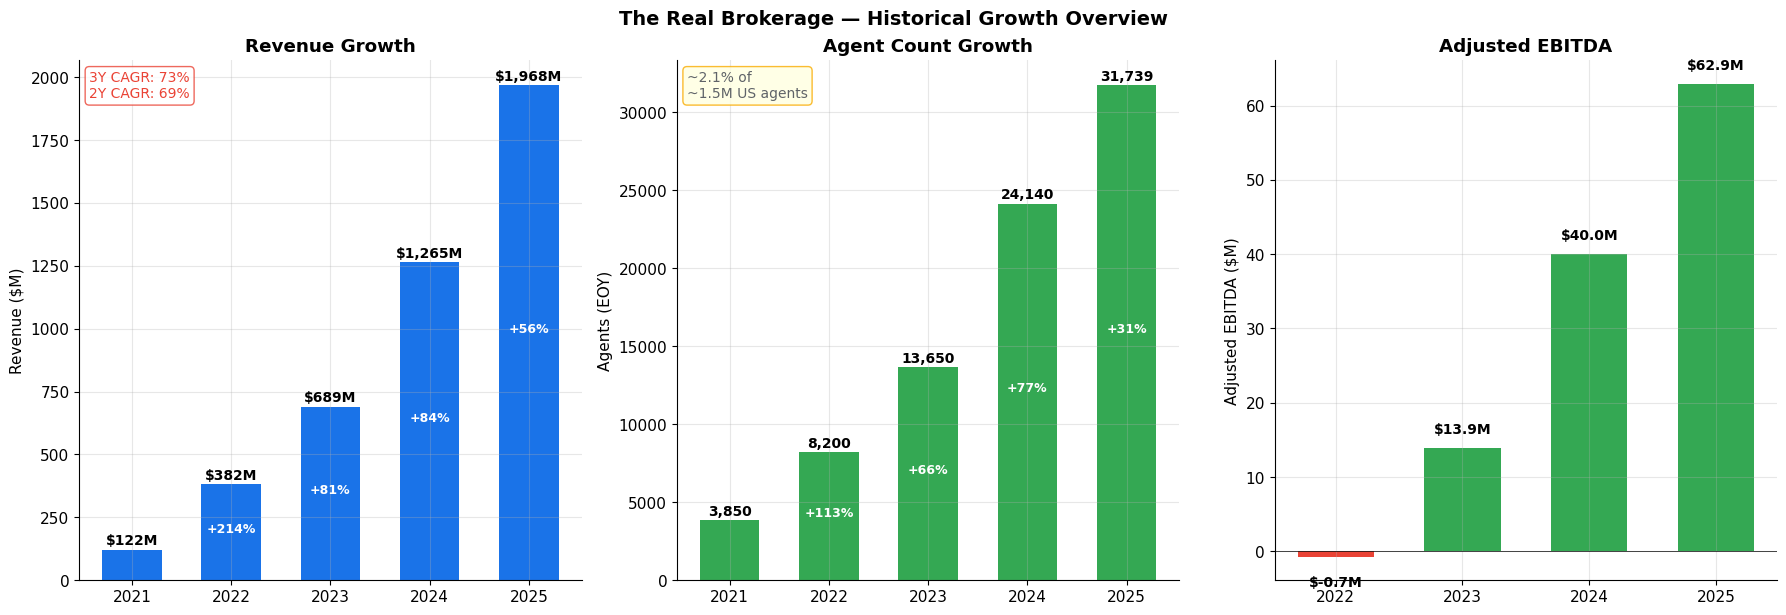

In [8]:
# ============================================================
# CELL GROUP 2: HISTORICAL ANALYSIS — Revenue & Growth
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Revenue growth waterfall
years = historical_annual.index.tolist()
revs = historical_annual['Revenue_M'].values
ax = axes[0]
ax.bar(range(len(years)), revs, color=COLORS['primary'], width=0.6)
for i, (y, r) in enumerate(zip(years, revs)):
    ax.text(i, r + 20, f'${r:,.0f}M', ha='center', fontsize=10, fontweight='bold')
    if i > 0 and not np.isnan(historical_annual['YoY_Growth'].iloc[i]):
        g = historical_annual['YoY_Growth'].iloc[i]
        ax.text(i, r/2, f'+{g:.0%}', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Revenue Growth', fontweight='bold')

# CAGR calculations
cagr_3yr = (1968.4 / 381.8) ** (1/3) - 1
cagr_2yr = (1968.4 / 689.2) ** (1/2) - 1
ax.text(0.02, 0.98, f'3Y CAGR: {cagr_3yr:.0%}\n2Y CAGR: {cagr_2yr:.0%}',
        transform=ax.transAxes, va='top', fontsize=10, color=COLORS['accent'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLORS['accent'], alpha=0.8))

# 2) Agent count growth
ax = axes[1]
agents = historical_annual['Agents_EOY'].values
ax.bar(range(len(years)), agents, color=COLORS['secondary'], width=0.6)
for i, (y, a) in enumerate(zip(years, agents)):
    ax.text(i, a + 300, f'{a:,}', ha='center', fontsize=10, fontweight='bold')
    if i > 0:
        g = agents[i] / agents[i-1] - 1
        ax.text(i, a/2, f'+{g:.0%}', ha='center', fontsize=9, color='white', fontweight='bold')
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years)
ax.set_ylabel('Agents (EOY)')
ax.set_title('Agent Count Growth', fontweight='bold')
ax.text(0.02, 0.98, f'~{31739/1_500_000:.1%} of\n~1.5M US agents',
        transform=ax.transAxes, va='top', fontsize=10, color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor=COLORS['gold'], alpha=0.8))

# 3) Adj EBITDA
ax = axes[2]
ebitda_years = [2022, 2023, 2024, 2025]
ebitda_vals = [-0.7, 13.9, 40.0, 62.9]
colors_bar = [COLORS['accent'] if v < 0 else COLORS['secondary'] for v in ebitda_vals]
ax.bar(range(len(ebitda_years)), ebitda_vals, color=colors_bar, width=0.6)
for i, (y, e) in enumerate(zip(ebitda_years, ebitda_vals)):
    offset = 2 if e >= 0 else -4
    ax.text(i, e + offset, f'${e:,.1f}M', ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xticks(range(len(ebitda_years)))
ax.set_xticklabels(ebitda_years)
ax.set_ylabel('Adjusted EBITDA ($M)')
ax.set_title('Adjusted EBITDA', fontweight='bold')

plt.tight_layout()
plt.suptitle('The Real Brokerage — Historical Growth Overview', fontsize=14, fontweight='bold', y=1.02)
plt.show()

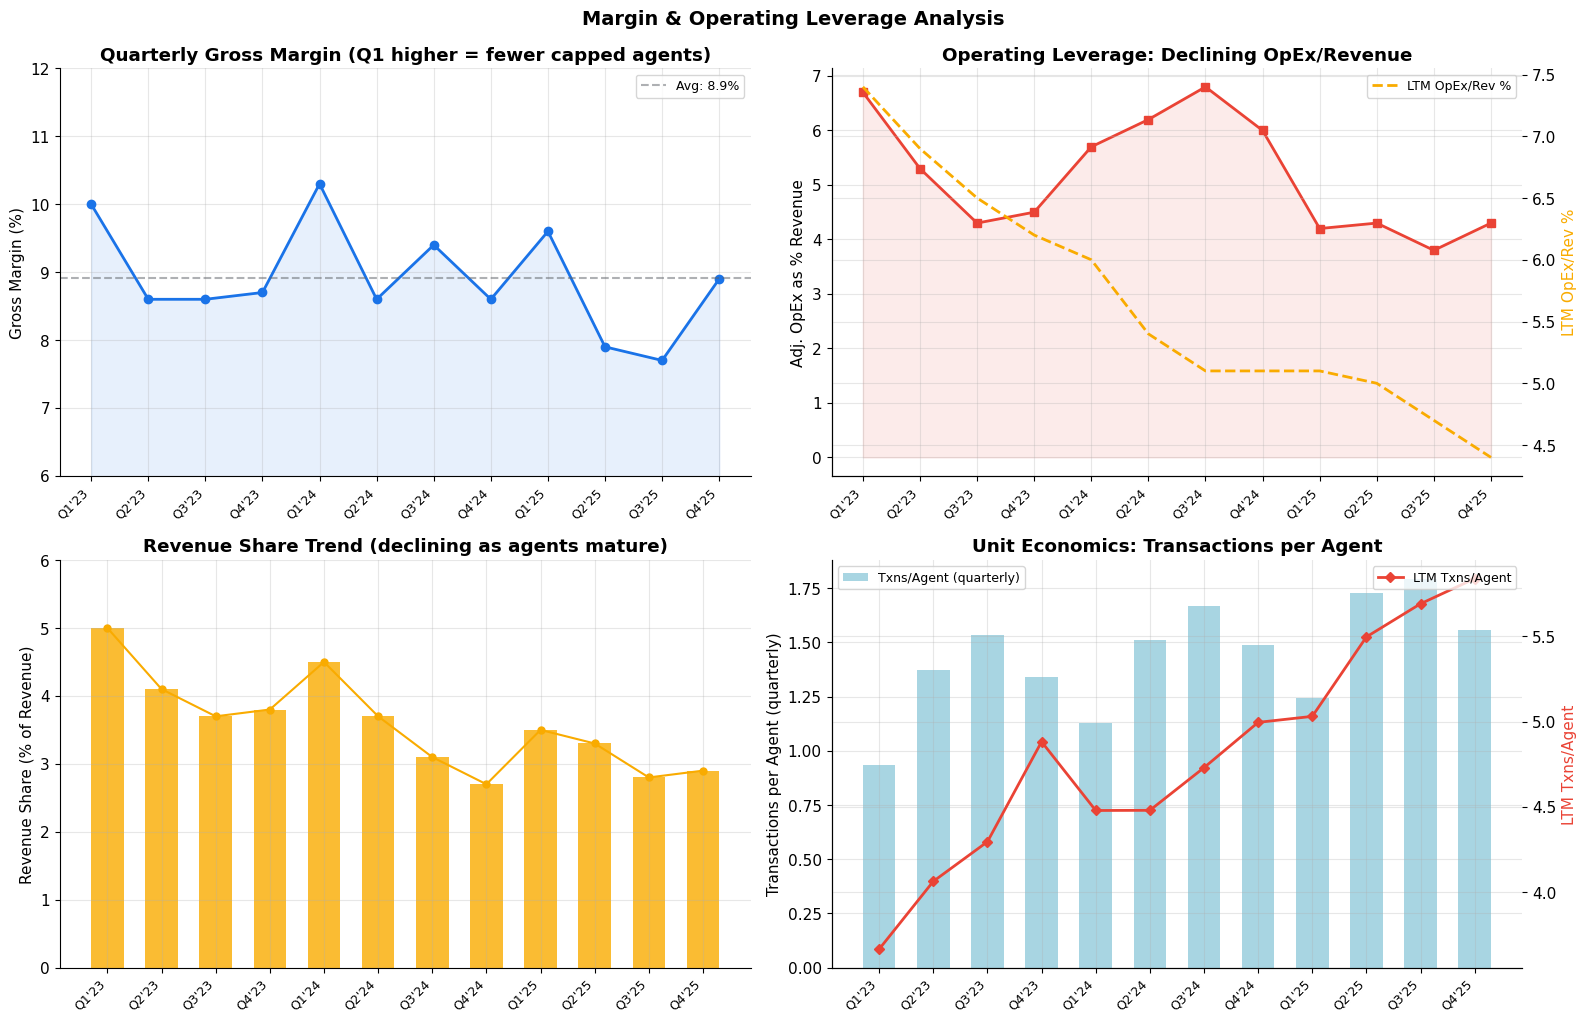


── Key Unit Economics ──
2025 Revenue/Agent (annual):  $62K
2025 LTM Txns/Agent:          5.8
2025 Rev/Transaction:          $10,622
2025 Avg Sale Price (GMV/Txn): $406,337
2025 Take Rate (Rev/GMV):      2.61%
2025 Gross Margin:             8.4%
2025 Adj EBITDA Margin:        3.2%


In [9]:
# ── Quarterly Margin & Operating Leverage Analysis ───────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1) Gross margin trend (quarterly)
ax = axes[0, 0]
ax.plot(range(len(quarters)), qkpi['Gross_Margin_Pct'], 'o-', color=COLORS['primary'], linewidth=2, markersize=6)
ax.axhline(y=qkpi['Gross_Margin_Pct'].mean(), color=COLORS['neutral'], linestyle='--', alpha=0.5, label=f'Avg: {qkpi["Gross_Margin_Pct"].mean():.1f}%')
ax.fill_between(range(len(quarters)), qkpi['Gross_Margin_Pct'], alpha=0.1, color=COLORS['primary'])
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Gross Margin (%)')
ax.set_title('Quarterly Gross Margin (Q1 higher = fewer capped agents)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(6, 12)

# 2) Operating leverage: Adj OpEx as % of revenue
ax = axes[0, 1]
ax.plot(range(len(quarters)), qkpi['AdjOpex_Pct_Rev'], 's-', color=COLORS['accent'], linewidth=2, markersize=6)
ax.fill_between(range(len(quarters)), qkpi['AdjOpex_Pct_Rev'], alpha=0.1, color=COLORS['accent'])
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Adj. OpEx as % Revenue')
ax.set_title('Operating Leverage: Declining OpEx/Revenue', fontweight='bold')
# Add LTM trend
ltm_opex_pct = [7.4, 6.9, 6.5, 6.2, 6.0, 5.4, 5.1, 5.1, 5.1, 5.0, 4.7, 4.4]
ax2 = ax.twinx()
ax2.plot(range(len(quarters)), ltm_opex_pct, '--', color=COLORS['gold'], linewidth=2, label='LTM OpEx/Rev %')
ax2.set_ylabel('LTM OpEx/Rev %', color=COLORS['gold'])
ax2.legend(loc='upper right', fontsize=9)

# 3) Revenue share as % of revenue
ax = axes[1, 0]
ax.bar(range(len(quarters)), qkpi['RevShare_Pct_Rev'], color=COLORS['gold'], width=0.6, alpha=0.8)
ax.plot(range(len(quarters)), qkpi['RevShare_Pct_Rev'], 'o-', color=COLORS['gold'], linewidth=1.5, markersize=5)
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Revenue Share (% of Revenue)')
ax.set_title('Revenue Share Trend (declining as agents mature)', fontweight='bold')
ax.set_ylim(0, 6)

# 4) Unit economics: Revenue per agent, Transactions per agent
ax = axes[1, 1]
# Annualized transactions per agent (quarterly * 4 is rough; use LTM)
ax.bar(range(len(quarters)), qkpi['Txns_Per_Agent'], color=COLORS['light'], width=0.6, label='Txns/Agent (quarterly)')
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Transactions per Agent (quarterly)')
ax.set_title('Unit Economics: Transactions per Agent', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)

# Overlay annualized (LTM) txns per agent
ltm_txns_per_agent = ltm['LTM_Transactions'] / qkpi['Agent_Count']
ax2 = ax.twinx()
ax2.plot(range(len(quarters)), ltm_txns_per_agent, 'D-', color=COLORS['accent'], linewidth=2, markersize=5, label='LTM Txns/Agent')
ax2.set_ylabel('LTM Txns/Agent', color=COLORS['accent'])
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.suptitle('Margin & Operating Leverage Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Print key metrics
print('\n── Key Unit Economics ──')
print(f'2025 Revenue/Agent (annual):  ${1968.4*1000/31739:,.0f}K')
print(f'2025 LTM Txns/Agent:          {185314/31739:.1f}')
print(f'2025 Rev/Transaction:          ${1968416/185314*1000:,.0f}')
print(f'2025 Avg Sale Price (GMV/Txn): ${75.3e9/185314:,.0f}')
print(f'2025 Take Rate (Rev/GMV):      {1968.4/75300*100:.2f}%')
print(f'2025 Gross Margin:             {165688/1968416*100:.1f}%')
print(f'2025 Adj EBITDA Margin:        {62.9/1968.4*100:.1f}%')

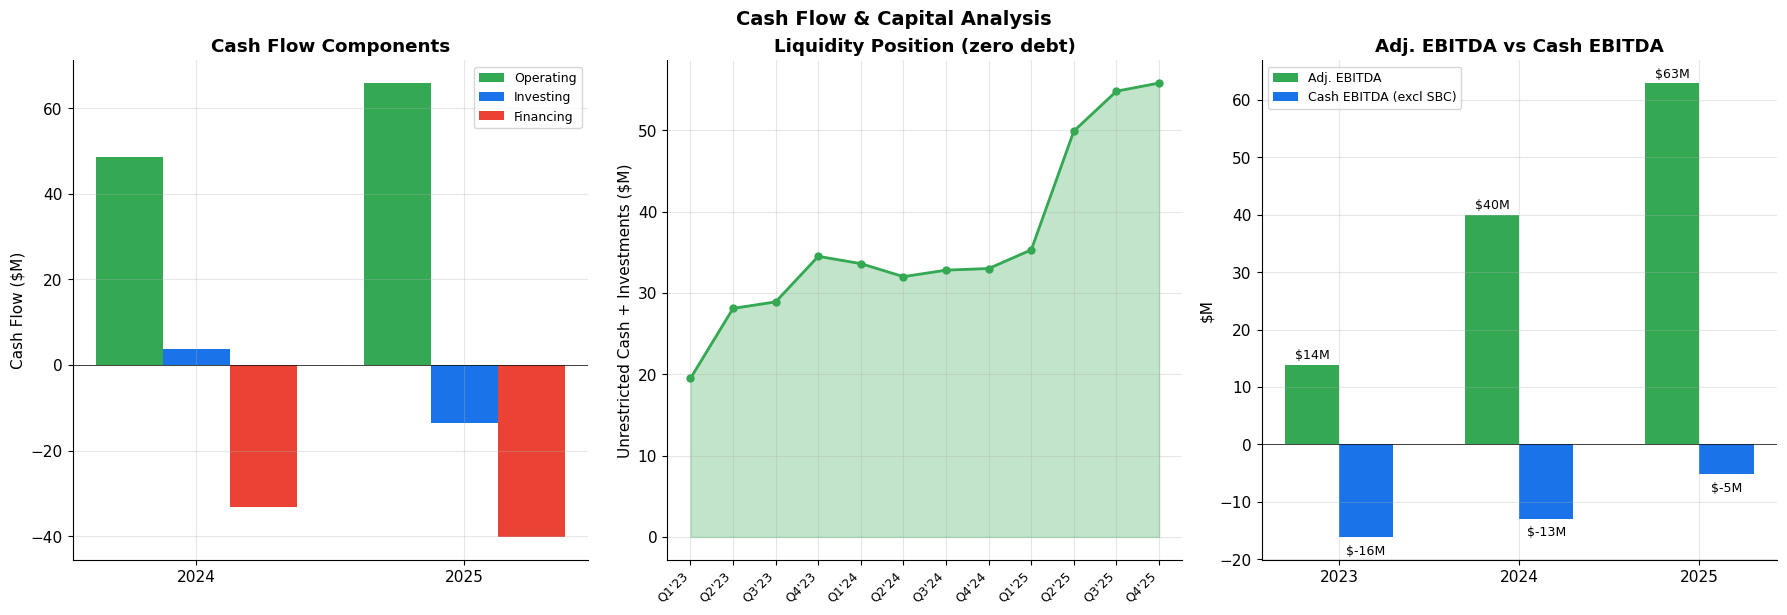


── Free Cash Flow ──
2024 FCF: $47.7M  (CFO $48.7M - Capex $1.0M)
2025 FCF: $62.1M  (CFO $65.9M - Capex $3.9M)

Note: CFO includes SBC add-back of $52.9M (2024) / $68.1M (2025)
Share buybacks in 2025: $39.4M (financing activity, not in FCF)


In [10]:
# ── Cash Flow & Balance Sheet Analysis ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Cash flow components
ax = axes[0]
cf_years = [2024, 2025]
cfo = [48.7, 65.9]
cfi = [3.8, -13.6]
cff = [-33.1, -40.2]
x = np.arange(len(cf_years))
w = 0.25
ax.bar(x - w, cfo, w, label='Operating', color=COLORS['secondary'])
ax.bar(x, cfi, w, label='Investing', color=COLORS['primary'])
ax.bar(x + w, cff, w, label='Financing', color=COLORS['accent'])
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cf_years)
ax.set_ylabel('Cash Flow ($M)')
ax.set_title('Cash Flow Components', fontweight='bold')
ax.legend(fontsize=9)

# 2) Cash + Investments over time (quarterly)
ax = axes[1]
ax.fill_between(range(len(quarters)), ltm['Cash_Investments_M'], alpha=0.3, color=COLORS['secondary'])
ax.plot(range(len(quarters)), ltm['Cash_Investments_M'], 'o-', color=COLORS['secondary'], linewidth=2, markersize=5)
ax.set_xticks(range(len(quarters)))
ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Unrestricted Cash + Investments ($M)')
ax.set_title('Liquidity Position (zero debt)', fontweight='bold')

# 3) SBC vs Cash EBITDA
ax = axes[2]
sbc_vals = [30.0, 52.9, 68.1]
ebitda_vals_3 = [13.9, 40.0, 62.9]
# Cash EBITDA = Adj EBITDA - SBC (in COGS + marketing agents)
# SBC in COGS: 32.5 (2024), 43.7 (2025); SBC agents marketing: 10.1, 14.7
# But Adj EBITDA already adds back all SBC. Cash Adj EBITDA ≈ Adj EBITDA - total SBC
cash_ebitda = [e - s for e, s in zip(ebitda_vals_3, sbc_vals)]
yrs = [2023, 2024, 2025]
x = np.arange(len(yrs))
w = 0.3
ax.bar(x - w/2, ebitda_vals_3, w, label='Adj. EBITDA', color=COLORS['secondary'])
ax.bar(x + w/2, cash_ebitda, w, label='Cash EBITDA (excl SBC)', color=COLORS['primary'])
ax.axhline(y=0, color='black', linewidth=0.5)
for i in range(len(yrs)):
    ax.text(i - w/2, ebitda_vals_3[i] + 1, f'${ebitda_vals_3[i]:.0f}M', ha='center', fontsize=9)
    ax.text(i + w/2, min(cash_ebitda[i], 0) - 3, f'${cash_ebitda[i]:.0f}M', ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(yrs)
ax.set_ylabel('$M')
ax.set_title('Adj. EBITDA vs Cash EBITDA', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle('Cash Flow & Capital Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Free cash flow
capex_24 = 1.0
capex_25 = 1.1 + 2.75  # PPE + intangibles
fcf_24 = 48.7 - capex_24
fcf_25 = 65.9 - (capex_25)
print(f'\n── Free Cash Flow ──')
print(f'2024 FCF: ${fcf_24:.1f}M  (CFO ${48.7:.1f}M - Capex ${capex_24:.1f}M)')
print(f'2025 FCF: ${fcf_25:.1f}M  (CFO ${65.9:.1f}M - Capex ${capex_25:.1f}M)')
print(f'\nNote: CFO includes SBC add-back of $52.9M (2024) / $68.1M (2025)')
print(f'Share buybacks in 2025: $39.4M (financing activity, not in FCF)')

# Cell Group 3: Bottom-Up Operating Model (2026-2030)

Three scenarios (Bull, Base, Bear) with different assumptions for agent growth, margins, and operating leverage.

In [11]:
# ============================================================
# CELL GROUP 3: BOTTOM-UP OPERATING MODEL — Assumptions
# ============================================================

proj_years = [2026, 2027, 2028, 2029, 2030]

# ── Financial Services Assumptions ───────────────────────────
# Per-segment COGS rates from 2025 segment data
# Title: 82.3% GM → 17.7% COGS | Mortgage: 47.7% GM → 52.3% COGS | Wallet: 77.1% GM → 22.9% COGS
fs_cogs_pct = {'Title': 0.177, 'Mortgage': 0.523, 'Wallet': 0.229}

# Revenue per attached transaction ($K), grows modestly with ASP
fs_rev_per_txn = {
    'Title':    {2026: 10.0, 2027: 10.2, 2028: 10.4, 2029: 10.6, 2030: 10.8},
    'Mortgage': {2026: 4.0,  2027: 4.1,  2028: 4.2,  2029: 4.3,  2030: 4.4},
    'Wallet':   {2026: 0.20, 2027: 0.23, 2028: 0.26, 2029: 0.29, 2030: 0.32},
}

# ── Scenario Assumptions ─────────────────────────────────────

scenarios = {
    'Bull': {
        'agent_growth':     {2026: 0.28, 2027: 0.24, 2028: 0.20, 2029: 0.17, 2030: 0.15},
        'txns_per_agent':   {2026: 6.0,  2027: 6.1,  2028: 6.2,  2029: 6.3,  2030: 6.4},
        'asp_growth':       {2026: 0.03, 2027: 0.03, 2028: 0.03, 2029: 0.03, 2030: 0.03},
        'take_rate':        {2026: 0.026, 2027: 0.026, 2028: 0.026, 2029: 0.026, 2030: 0.026},
        'gross_margin':     {2026: 9.0,  2027: 9.5,  2028: 10.0, 2029: 10.5, 2030: 11.0},
        'revshare_pct':     {2026: 3.0,  2027: 2.9,  2028: 2.8,  2029: 2.7,  2030: 2.6},
        'adj_opex_pct':     {2026: 4.0,  2027: 3.7,  2028: 3.5,  2029: 3.3,  2030: 3.2},
        'sbc_pct_rev':      {2026: 3.2,  2027: 2.9,  2028: 2.6,  2029: 2.4,  2030: 2.2},
        'fs_attach': {
            'Title':    {2026: 0.025, 2027: 0.04, 2028: 0.06, 2029: 0.08, 2030: 0.10},
            'Mortgage': {2026: 0.015, 2027: 0.025, 2028: 0.04, 2029: 0.06, 2030: 0.08},
            'Wallet':   {2026: 0.03, 2027: 0.05, 2028: 0.09, 2029: 0.14, 2030: 0.20},
        },
    },
    'Base': {
        'agent_growth':     {2026: 0.22, 2027: 0.18, 2028: 0.15, 2029: 0.13, 2030: 0.11},
        'txns_per_agent':   {2026: 5.9,  2027: 5.9,  2028: 6.0,  2029: 6.0,  2030: 6.1},
        'asp_growth':       {2026: 0.025, 2027: 0.025, 2028: 0.025, 2029: 0.02, 2030: 0.02},
        'take_rate':        {2026: 0.026, 2027: 0.026, 2028: 0.026, 2029: 0.026, 2030: 0.026},
        'gross_margin':     {2026: 8.8,  2027: 9.2,  2028: 9.5,  2029: 9.8,  2030: 10.0},
        'revshare_pct':     {2026: 3.0,  2027: 3.0,  2028: 2.9,  2029: 2.9,  2030: 2.8},
        'adj_opex_pct':     {2026: 4.2,  2027: 4.0,  2028: 3.8,  2029: 3.6,  2030: 3.5},
        'sbc_pct_rev':      {2026: 3.3,  2027: 3.0,  2028: 2.8,  2029: 2.6,  2030: 2.4},
        'fs_attach': {
            'Title':    {2026: 0.02, 2027: 0.03, 2028: 0.045, 2029: 0.06, 2030: 0.08},
            'Mortgage': {2026: 0.01, 2027: 0.02, 2028: 0.03, 2029: 0.045, 2030: 0.06},
            'Wallet':   {2026: 0.02, 2027: 0.04, 2028: 0.07, 2029: 0.11, 2030: 0.15},
        },
    },
    'Bear': {
        'agent_growth':     {2026: 0.15, 2027: 0.12, 2028: 0.10, 2029: 0.08, 2030: 0.06},
        'txns_per_agent':   {2026: 5.7,  2027: 5.7,  2028: 5.7,  2029: 5.7,  2030: 5.8},
        'asp_growth':       {2026: 0.02, 2027: 0.02, 2028: 0.015, 2029: 0.015, 2030: 0.015},
        'take_rate':        {2026: 0.026, 2027: 0.026, 2028: 0.025, 2029: 0.025, 2030: 0.025},
        'gross_margin':     {2026: 8.5,  2027: 8.7,  2028: 8.8,  2029: 9.0,  2030: 9.2},
        'revshare_pct':     {2026: 3.1,  2027: 3.1,  2028: 3.0,  2029: 3.0,  2030: 3.0},
        'adj_opex_pct':     {2026: 4.5,  2027: 4.3,  2028: 4.2,  2029: 4.1,  2030: 4.0},
        'sbc_pct_rev':      {2026: 3.5,  2027: 3.3,  2028: 3.1,  2029: 3.0,  2030: 2.8},
        'fs_attach': {
            'Title':    {2026: 0.015, 2027: 0.02, 2028: 0.03, 2029: 0.04, 2030: 0.05},
            'Mortgage': {2026: 0.008, 2027: 0.012, 2028: 0.02, 2029: 0.03, 2030: 0.04},
            'Wallet':   {2026: 0.015, 2027: 0.025, 2028: 0.04, 2029: 0.065, 2030: 0.09},
        },
    },
}

# Print assumption summary
print('── Scenario Assumptions Summary ──\n')
for scenario_name in ['Bull', 'Base', 'Bear']:
    s = scenarios[scenario_name]
    print(f'  {scenario_name.upper()} CASE:')
    print(f'    Agent growth:    {s["agent_growth"][2026]:.0%} → {s["agent_growth"][2030]:.0%}')
    print(f'    Txns/agent:      {s["txns_per_agent"][2026]:.1f} → {s["txns_per_agent"][2030]:.1f}')
    print(f'    Brokerage GM:    {s["gross_margin"][2026]:.1f}% → {s["gross_margin"][2030]:.1f}%')
    print(f'    Rev share:       {s["revshare_pct"][2026]:.1f}% → {s["revshare_pct"][2030]:.1f}%')
    print(f'    Adj OpEx/Rev:    {s["adj_opex_pct"][2026]:.1f}% → {s["adj_opex_pct"][2030]:.1f}%')
    print(f'    SBC/Rev:         {s["sbc_pct_rev"][2026]:.1f}% → {s["sbc_pct_rev"][2030]:.1f}%')
    print(f'    FS Attach 2030:  Title {s["fs_attach"]["Title"][2030]:.0%}  '
          f'Mortgage {s["fs_attach"]["Mortgage"][2030]:.0%}  '
          f'Wallet {s["fs_attach"]["Wallet"][2030]:.0%}')
    print()

── Scenario Assumptions Summary ──

  BULL CASE:
    Agent growth:    28% → 15%
    Txns/agent:      6.0 → 6.4
    Brokerage GM:    9.0% → 11.0%
    Rev share:       3.0% → 2.6%
    Adj OpEx/Rev:    4.0% → 3.2%
    SBC/Rev:         3.2% → 2.2%
    FS Attach 2030:  Title 10%  Mortgage 8%  Wallet 20%

  BASE CASE:
    Agent growth:    22% → 11%
    Txns/agent:      5.9 → 6.1
    Brokerage GM:    8.8% → 10.0%
    Rev share:       3.0% → 2.8%
    Adj OpEx/Rev:    4.2% → 3.5%
    SBC/Rev:         3.3% → 2.4%
    FS Attach 2030:  Title 8%  Mortgage 6%  Wallet 15%

  BEAR CASE:
    Agent growth:    15% → 6%
    Txns/agent:      5.7 → 5.8
    Brokerage GM:    8.5% → 9.2%
    Rev share:       3.1% → 3.0%
    Adj OpEx/Rev:    4.5% → 4.0%
    SBC/Rev:         3.5% → 2.8%
    FS Attach 2030:  Title 5%  Mortgage 4%  Wallet 9%



In [12]:
# ── Build Bottom-Up Projections for All Scenarios ────────────

def build_projection(scenario_name, assumptions):
    """Build bottom-up revenue and operating model with per-segment financial services."""
    a = assumptions

    # Starting values from 2025 actuals
    agents_prev = 31_739
    asp_prev = 75.3e6 / 185_314  # ~$406K from GMV/transactions

    rows = []
    for yr in proj_years:
        # Agent count
        agents = int(agents_prev * (1 + a['agent_growth'][yr]))

        # Transactions
        txns = int(agents * a['txns_per_agent'][yr])

        # Average sale price
        asp = asp_prev * (1 + a['asp_growth'][yr])

        # GMV
        gmv = txns * asp

        # ── Brokerage Revenue ────────────────────────────────
        brokerage_rev = gmv * a['take_rate'][yr]
        brokerage_gp = brokerage_rev * a['gross_margin'][yr] / 100
        brokerage_cogs = brokerage_rev - brokerage_gp

        # ── Financial Services: Per-Segment Bottom-Up ────────
        fs_data = {}
        for segment in ['Title', 'Mortgage', 'Wallet']:
            attach = a['fs_attach'][segment][yr]
            rev_per = fs_rev_per_txn[segment][yr]
            seg_rev = txns * attach * rev_per
            seg_cogs = seg_rev * fs_cogs_pct[segment]
            seg_gp = seg_rev - seg_cogs
            fs_data[segment] = {'rev': seg_rev, 'cogs': seg_cogs, 'gp': seg_gp}

        fs_rev = sum(d['rev'] for d in fs_data.values())
        fs_cogs_total = sum(d['cogs'] for d in fs_data.values())
        fs_gp = sum(d['gp'] for d in fs_data.values())

        # ── Totals with blended margin ───────────────────────
        total_rev = brokerage_rev + fs_rev
        total_cogs = brokerage_cogs + fs_cogs_total
        gross_profit = total_rev - total_cogs
        blended_gm_pct = gross_profit / total_rev * 100

        # Revenue share
        rev_share = total_rev * a['revshare_pct'][yr] / 100

        # Adjusted operating expense (excl rev share, excl SBC)
        adj_opex_cash = total_rev * a['adj_opex_pct'][yr] / 100

        # SBC
        sbc = total_rev * a['sbc_pct_rev'][yr] / 100

        # Adjusted EBITDA = Gross Profit - Rev Share - Adj OpEx (cash)
        adj_ebitda = gross_profit - rev_share - adj_opex_cash

        # GAAP operating income = Adj EBITDA - SBC - D&A
        da = intangible_amort_schedule.get(yr, 275) + 800 + (yr - 2025) * 100
        gaap_op_income = adj_ebitda - sbc - da

        rows.append({
            'Year': yr,
            'Scenario': scenario_name,
            'Agents': agents,
            'Agent_Growth': a['agent_growth'][yr],
            'Transactions': txns,
            'Txns_Per_Agent': a['txns_per_agent'][yr],
            'ASP': asp,
            'GMV': gmv,
            'Take_Rate': a['take_rate'][yr],
            'Brokerage_Rev': brokerage_rev,
            'Brokerage_COGS': brokerage_cogs,
            'Brokerage_GP': brokerage_gp,
            'Brokerage_GM_Pct': a['gross_margin'][yr],
            'Title_Rev': fs_data['Title']['rev'],
            'Title_COGS': fs_data['Title']['cogs'],
            'Title_GP': fs_data['Title']['gp'],
            'Mortgage_Rev': fs_data['Mortgage']['rev'],
            'Mortgage_COGS': fs_data['Mortgage']['cogs'],
            'Mortgage_GP': fs_data['Mortgage']['gp'],
            'Wallet_Rev': fs_data['Wallet']['rev'],
            'Wallet_COGS': fs_data['Wallet']['cogs'],
            'Wallet_GP': fs_data['Wallet']['gp'],
            'FS_Revenue': fs_rev,
            'FS_COGS': fs_cogs_total,
            'FS_GP': fs_gp,
            'Total_Revenue': total_rev,
            'COGS': total_cogs,
            'Gross_Profit': gross_profit,
            'Gross_Margin_Pct': blended_gm_pct,
            'Revenue_Share': rev_share,
            'RevShare_Pct': a['revshare_pct'][yr],
            'Adj_Cash_OpEx': adj_opex_cash,
            'AdjOpex_Pct': a['adj_opex_pct'][yr],
            'SBC': sbc,
            'SBC_Pct': a['sbc_pct_rev'][yr],
            'DA': da,
            'Adj_EBITDA': adj_ebitda,
            'GAAP_Op_Income': gaap_op_income,
        })

        agents_prev = agents
        asp_prev = asp

    return pd.DataFrame(rows).set_index('Year')

# Build all scenarios
projections = {}
for name, assumptions in scenarios.items():
    projections[name] = build_projection(name, assumptions)

# Display Base case summary
base = projections['Base']
print('── BASE CASE PROJECTIONS ($thousands) ──\n')
display_cols = ['Agents', 'Transactions', 'Brokerage_Rev', 'FS_Revenue', 'Total_Revenue',
                'Gross_Profit', 'Gross_Margin_Pct', 'Brokerage_GM_Pct', 'Adj_EBITDA']
summary = base[display_cols].copy()
for col in ['Brokerage_Rev', 'FS_Revenue', 'Total_Revenue', 'Gross_Profit', 'Adj_EBITDA']:
    summary[col] = summary[col] / 1000
summary.columns = ['Agents', 'Txns', 'Brok Rev ($M)', 'FS Rev ($M)', 'Total Rev ($M)',
                    'GP ($M)', 'Blended GM%', 'Brok GM%', 'Adj EBITDA ($M)']
summary

── BASE CASE PROJECTIONS ($thousands) ──



,Agents,Txns,Brok Rev ($M),FS Rev ($M),Total Rev ($M),GP ($M),Blended GM%,Brok GM%,Adj EBITDA ($M)
Year,,,,,,,,,
2026,38721,228453,2473.892504,55.742532,2529.635036,260.369336,10.292763,8.8,78.235614
2027,45690,269571,2992.133691,107.073601,3099.207292,355.620642,11.474568,9.2,138.676132
2028,52543,315258,3586.722738,193.000948,3779.723686,485.536092,12.845809,9.5,232.294605
2029,59373,356238,4134.015547,306.863413,4440.878961,633.240695,14.259355,9.8,344.583562
2030,65904,402014,4758.534375,472.768464,5231.302839,827.216890,15.812827,10.0,497.644811


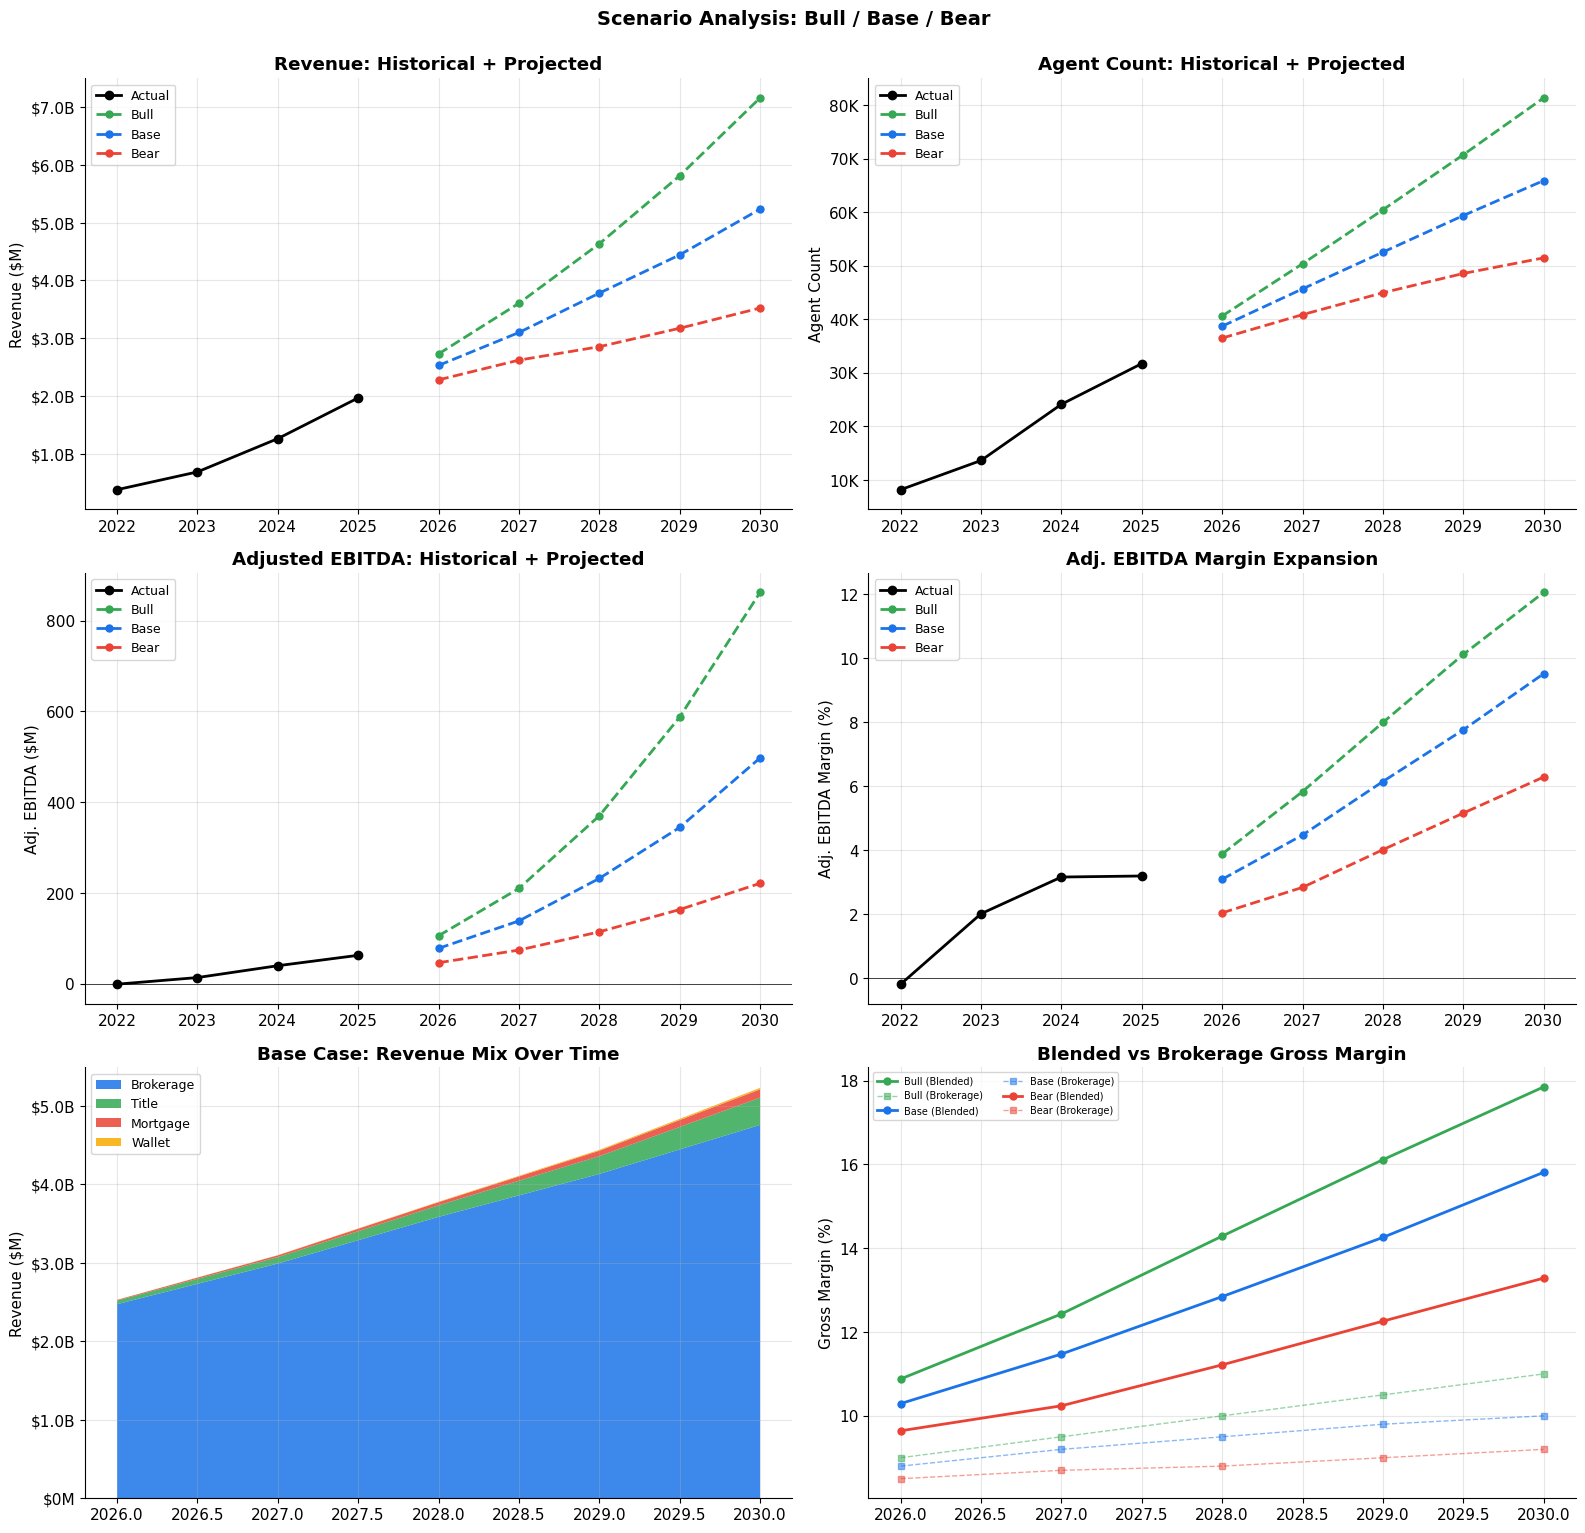

In [13]:
# ── Scenario Comparison Charts ───────────────────────────────

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'], 'Bear': COLORS['accent']}

# Historical + projected revenue
ax = axes[0, 0]
hist_yrs = [2022, 2023, 2024, 2025]
hist_rev = [381.8, 689.2, 1264.6, 1968.4]
ax.plot(hist_yrs, hist_rev, 'ko-', linewidth=2, markersize=6, label='Actual')
for name, proj in projections.items():
    rev = proj['Total_Revenue'] / 1e3
    ax.plot(proj_years, rev, 'o--', color=scenario_colors[name], linewidth=2, markersize=5, label=name)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Revenue: Historical + Projected', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.1f}B' if x >= 1000 else f'${x:.0f}M'))

# Agent count
ax = axes[0, 1]
hist_agents = [8_200, 13_650, 24_140, 31_739]
ax.plot(hist_yrs, hist_agents, 'ko-', linewidth=2, markersize=6, label='Actual')
for name, proj in projections.items():
    ax.plot(proj_years, proj['Agents'], 'o--', color=scenario_colors[name], linewidth=2, markersize=5, label=name)
ax.set_ylabel('Agent Count')
ax.set_title('Agent Count: Historical + Projected', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Adjusted EBITDA
ax = axes[1, 0]
hist_ebitda = [-0.7, 13.9, 40.0, 62.9]
ax.plot(hist_yrs, hist_ebitda, 'ko-', linewidth=2, markersize=6, label='Actual')
for name, proj in projections.items():
    ax.plot(proj_years, proj['Adj_EBITDA'] / 1e3, 'o--', color=scenario_colors[name], linewidth=2, markersize=5, label=name)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Adj. EBITDA ($M)')
ax.set_title('Adjusted EBITDA: Historical + Projected', fontweight='bold')
ax.legend(fontsize=9)

# Adj EBITDA margin
ax = axes[1, 1]
hist_ebitda_margin = [-0.7/381.8*100, 13.9/689.2*100, 40.0/1264.6*100, 62.9/1968.4*100]
ax.plot(hist_yrs, hist_ebitda_margin, 'ko-', linewidth=2, markersize=6, label='Actual')
for name, proj in projections.items():
    margin = proj['Adj_EBITDA'] / proj['Total_Revenue'] * 100
    ax.plot(proj_years, margin, 'o--', color=scenario_colors[name], linewidth=2, markersize=5, label=name)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('Adj. EBITDA Margin (%)')
ax.set_title('Adj. EBITDA Margin Expansion', fontweight='bold')
ax.legend(fontsize=9)

# Revenue mix stacked area (Base case)
ax = axes[2, 0]
base_p = projections['Base']
brok = base_p['Brokerage_Rev'] / 1e3
title = base_p['Title_Rev'] / 1e3
mortgage = base_p['Mortgage_Rev'] / 1e3
wallet = base_p['Wallet_Rev'] / 1e3
ax.stackplot(proj_years, brok, title, mortgage, wallet,
             labels=['Brokerage', 'Title', 'Mortgage', 'Wallet'],
             colors=[COLORS['primary'], COLORS['secondary'], COLORS['accent'], COLORS['gold']],
             alpha=0.85)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Base Case: Revenue Mix Over Time', fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.1f}B' if x >= 1000 else f'${x:.0f}M'))

# Blended gross margin vs brokerage-only margin
ax = axes[2, 1]
for name, proj in projections.items():
    blended = proj['Gross_Margin_Pct']
    ax.plot(proj_years, blended, 'o-', color=scenario_colors[name], linewidth=2, markersize=5, label=f'{name} (Blended)')
    brok_gm = proj['Brokerage_GM_Pct']
    ax.plot(proj_years, brok_gm, 's--', color=scenario_colors[name], linewidth=1, markersize=4, alpha=0.5, label=f'{name} (Brokerage)')
ax.set_ylabel('Gross Margin (%)')
ax.set_title('Blended vs Brokerage Gross Margin', fontweight='bold')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.suptitle('Scenario Analysis: Bull / Base / Bear', fontsize=14, fontweight='bold', y=1.02)
plt.show()

══════════════════════════════════════════════════════════════
  FINANCIAL SERVICES ATTACH RATE ASSUMPTIONS (% of Txns)
══════════════════════════════════════════════════════════════

  TITLE:
              2026    2027    2028    2029    2030
      Bull     2%      4%      6%      8%     10% 
      Base     2%      3%      4%      6%      8% 
      Bear     2%      2%      3%      4%      5% 

  MORTGAGE:
              2026    2027    2028    2029    2030
      Bull     2%      2%      4%      6%      8% 
      Base     1%      2%      3%      4%      6% 
      Bear     1%      1%      2%      3%      4% 

  WALLET:
              2026    2027    2028    2029    2030
      Bull     3%      5%      9%     14%     20% 
      Base     2%      4%      7%     11%     15% 
      Bear     2%      2%      4%      6%      9% 

  Revenue per attached txn ($K):
         Title: $10.0K  $10.2K  $10.4K  $10.6K  $10.8K
      Mortgage: $4.0K  $4.1K  $4.2K  $4.3K  $4.4K
        Wallet: $200  $230  $260

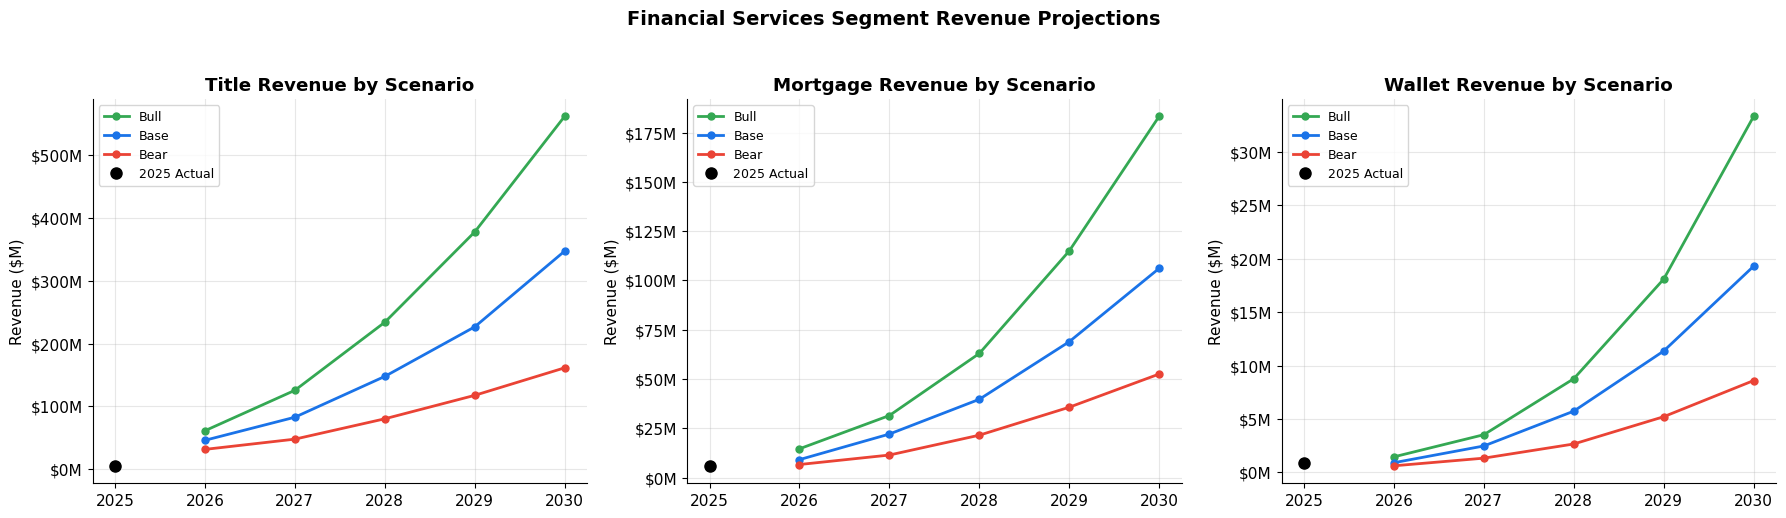


  FS Revenue as % of Total (Base Case):
    2026: 2.2%  (Title $46M  Mortgage $9M  Wallet $1M)
    2027: 3.5%  (Title $82M  Mortgage $22M  Wallet $2M)
    2028: 5.1%  (Title $148M  Mortgage $40M  Wallet $6M)
    2029: 6.9%  (Title $227M  Mortgage $69M  Wallet $11M)
    2030: 9.0%  (Title $347M  Mortgage $106M  Wallet $19M)


In [14]:
# ── Financial Services Growth Matrix ──────────────────────────

print('══════════════════════════════════════════════════════════════')
print('  FINANCIAL SERVICES ATTACH RATE ASSUMPTIONS (% of Txns)')
print('══════════════════════════════════════════════════════════════\n')

for segment in ['Title', 'Mortgage', 'Wallet']:
    print(f'  {segment.upper()}:')
    header = f'  {"":>8}' + ''.join(f'{yr:>8}' for yr in proj_years)
    print(header)
    for sc in ['Bull', 'Base', 'Bear']:
        rates = scenarios[sc]['fs_attach'][segment]
        row = f'  {sc:>8}' + ''.join(f'{rates[yr]:>7.0%} ' for yr in proj_years)
        print(row)
    print()

print(f'  Revenue per attached txn ($K):')
for segment in ['Title', 'Mortgage', 'Wallet']:
    vals = fs_rev_per_txn[segment]
    row = f'    {segment:>10}: ' + '  '.join(f'${vals[yr]:.1f}K' if vals[yr] >= 1 else f'${vals[yr]*1000:.0f}' for yr in proj_years)
    print(row)

print(f'\n  Segment gross margins: Title {(1-fs_cogs_pct["Title"]):.1%}  '
      f'Mortgage {(1-fs_cogs_pct["Mortgage"]):.1%}  '
      f'Wallet {(1-fs_cogs_pct["Wallet"]):.1%}')

# ── FS Revenue Comparison Across Scenarios ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'], 'Bear': COLORS['accent']}

for idx, segment in enumerate(['Title', 'Mortgage', 'Wallet']):
    ax = axes[idx]
    for name, proj in projections.items():
        rev_col = f'{segment}_Rev'
        ax.plot(proj_years, proj[rev_col] / 1e3, 'o-', color=scenario_colors[name],
                linewidth=2, markersize=5, label=name)
    # Add 2025 actual
    actuals_2025 = {'Title': 5.035, 'Mortgage': 6.009, 'Wallet': 0.889}
    ax.plot(2025, actuals_2025[segment], 'ko', markersize=8, label='2025 Actual')
    ax.set_title(f'{segment} Revenue by Scenario', fontweight='bold')
    ax.set_ylabel('Revenue ($M)')
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))

plt.suptitle('Financial Services Segment Revenue Projections', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# ── FS as % of Total Revenue ────────────────────────────────
print('\n  FS Revenue as % of Total (Base Case):')
base_p = projections['Base']
for yr in proj_years:
    fs_pct = base_p.loc[yr, 'FS_Revenue'] / base_p.loc[yr, 'Total_Revenue'] * 100
    print(f'    {yr}: {fs_pct:.1f}%  (Title ${base_p.loc[yr,"Title_Rev"]/1e3:.0f}M  '
          f'Mortgage ${base_p.loc[yr,"Mortgage_Rev"]/1e3:.0f}M  '
          f'Wallet ${base_p.loc[yr,"Wallet_Rev"]/1e3:.0f}M)')

# Cell Group 4: 3-Statement Projected Model (2026-2030)

Full income statement, balance sheet, and cash flow projections using the Base case operating model.

In [15]:
# ============================================================
# CELL GROUP 4: 3-STATEMENT MODEL (Base Case)
# ============================================================

def build_three_statement(proj_df, scenario_name='Base'):
    """Build projected income statement, balance sheet, cash flow from operating model."""

    # ── INCOME STATEMENT ─────────────────────────────────────
    is_rows = []

    # Historical actuals for reference
    hist_is = {
        2024: {'Revenue': 1_264_639, 'COGS': 1_149_898, 'Gross_Profit': 114_741,
               'Revenue_Share': 42_727, 'GA_Cash': 61_084 - 9_324, 'Marketing_Cash': 57_477 - 10_077 - 29 - 42_727,
               'RD_Cash': 12_156 - 949, 'SBC': 52_916, 'DA': 1_396, 'Settlement': 9_250,
               'Other_Income': 496, 'Finance_Expense': -1_723, 'Tax': 0, 'Net_Income': -26_453},
        2025: {'Revenue': 1_968_416, 'COGS': 1_802_728, 'Gross_Profit': 165_688,
               'Revenue_Share': 60_520, 'GA_Cash': 74_359 - 8_416, 'Marketing_Cash': 82_383 - 14_727 - 160 - 60_520,
               'RD_Cash': 17_443 - 1_158, 'SBC': 68_146, 'DA': 1_929, 'Settlement': 750,
               'Other_Income': 995, 'Finance_Expense': -554, 'Tax': -740, 'Net_Income': -8_066},
    }

    # NOL tracking ($thousands)
    nol_us = 44_680
    nol_canada = 12_276
    nol_israel = 4_048
    tax_rate = 0.27

    for yr in proj_years:
        p = proj_df.loc[yr]

        # Per-segment revenue and COGS from enhanced projections
        brokerage_rev = p['Brokerage_Rev']
        brokerage_cogs = p['Brokerage_COGS']
        fs_rev = p['FS_Revenue']
        fs_cogs_val = p['FS_COGS']

        rev = p['Total_Revenue']
        cogs = p['COGS']
        gp = p['Gross_Profit']
        rev_share = p['Revenue_Share']
        sbc = p['SBC']
        da = p['DA']

        # Cash operating expenses (excl rev share, excl SBC)
        adj_opex = p['Adj_Cash_OpEx']
        ga_cash = adj_opex * 0.72
        mktg_cash = adj_opex * 0.08
        rd_cash = adj_opex * 0.20

        # Total GAAP opex
        total_opex = rev_share + ga_cash + mktg_cash + rd_cash + sbc + da

        # Operating income
        op_income = gp - total_opex

        # Other income
        other_income = 1_500 + (yr - 2026) * 200
        finance_exp = -300

        pretax = op_income + other_income + finance_exp

        # Tax with NOL usage
        if pretax > 0:
            nol_total = nol_us + nol_canada + nol_israel
            taxable = max(0, pretax - nol_total)
            nol_used = min(nol_total, pretax)
            tax = -taxable * tax_rate
            if nol_total > 0:
                ratio = nol_used / nol_total
                nol_us -= nol_us * ratio
                nol_canada -= nol_canada * ratio
                nol_israel -= nol_israel * ratio
        else:
            tax = 0
            nol_us += abs(pretax) * 0.7
            nol_canada += abs(pretax) * 0.25
            nol_israel += abs(pretax) * 0.05

        net_income = pretax + tax

        is_rows.append({
            'Year': yr,
            'Brokerage_Revenue': brokerage_rev,
            'FS_Revenue': fs_rev,
            'Revenue': rev,
            'Brokerage_COGS': brokerage_cogs,
            'FS_COGS': fs_cogs_val,
            'COGS': cogs,
            'Gross_Profit': gp,
            'Gross_Margin_Pct': gp / rev * 100,
            'Revenue_Share': rev_share,
            'GA_Cash': ga_cash,
            'Marketing_Cash': mktg_cash,
            'RD_Cash': rd_cash,
            'SBC': sbc,
            'DA': da,
            'Total_OpEx': total_opex,
            'Operating_Income': op_income,
            'Other_Income': other_income,
            'Finance_Expense': finance_exp,
            'Pretax_Income': pretax,
            'Tax': tax,
            'Net_Income': net_income,
            'Adj_EBITDA': p['Adj_EBITDA'],
        })

    is_df = pd.DataFrame(is_rows).set_index('Year')

    # ── BALANCE SHEET ────────────────────────────────────────
    bs_rows = []

    prev_bs = {
        'Cash': 33_213, 'Restricted_Cash': 26_338, 'Investments': 16_731,
        'Trade_Receivables': 20_170, 'Financing_Recv': 8_542,
        'Other_CA': 3_081, 'PPE_Gross': 4_179, 'Accum_Depr': 1_724,
        'Intangibles': 4_157, 'Goodwill': 8_993, 'Equity_Sec': 2_250,
        'DTA': 931,
        'AP': 1_161, 'Accrued_Liab': 38_205, 'Customer_Deposits': 26_338,
        'Other_Payables': 9_562, 'DTL': 10,
        'APIC': 164_208, 'Accum_Deficit': -112_851, 'AOCI': 318,
        'Treasury': 0, 'NCI': -90,
    }
    prev_rev = 1_968_416
    shares_out = 210_478
    buyback_amount = 40_000

    for yr in proj_years:
        row = is_df.loc[yr]
        rev = row['Revenue']
        rev_growth = rev / prev_rev

        trade_recv_days = 3.7
        trade_recv = rev / 365 * trade_recv_days
        financing_recv = prev_bs['Financing_Recv'] * 1.1
        other_ca = prev_bs['Other_CA'] * 1.05

        capex = 1_200 + (yr - 2025) * 100
        ppe_gross = prev_bs['PPE_Gross'] + capex
        depr = 800 + (yr - 2025) * 100
        accum_depr = prev_bs['Accum_Depr'] + depr
        ppe_net = ppe_gross - accum_depr

        intang_amort = intangible_amort_schedule.get(yr, 275)
        intangibles = max(0, prev_bs['Intangibles'] - intang_amort)

        goodwill = 8_993
        equity_sec = prev_bs['Equity_Sec']
        restricted_cash = prev_bs['Restricted_Cash'] * 1.03
        investments = prev_bs['Investments'] * 1.05
        dta = prev_bs['DTA'] + 200 if row['Net_Income'] < 0 else max(0, prev_bs['DTA'] - 200)

        ap = rev / 365 * 0.22
        accrued_liab = rev * 0.0194
        customer_deposits = restricted_cash
        other_payables = rev * 0.00486
        dtl = 10

        sbc_is = row['SBC']
        net_inc = row['Net_Income']

        est_share_price = 5.0 * (1.10 ** (yr - 2025))
        shares_bought = buyback_amount / est_share_price
        sbc_shares = max(5_000, 17_515 - (yr - 2025) * 2_500)
        option_exercises = max(1_000, 4_390 - (yr - 2025) * 700)
        shares_out = shares_out + sbc_shares + option_exercises - shares_bought

        apic = prev_bs['APIC'] + sbc_is + option_exercises * 0.5
        accum_deficit = prev_bs['Accum_Deficit'] + net_inc
        aoci = prev_bs['AOCI']
        nci = prev_bs['NCI']

        total_equity = apic + accum_deficit + aoci + nci
        total_liab = ap + accrued_liab + customer_deposits + other_payables + dtl

        total_non_cash_assets = (trade_recv + financing_recv + other_ca + restricted_cash + investments +
                                 ppe_net + intangibles + goodwill + equity_sec + dta)
        cash = total_equity + total_liab - total_non_cash_assets
        total_assets = cash + total_non_cash_assets

        bs_rows.append({
            'Year': yr,
            'Cash': cash,
            'Restricted_Cash': restricted_cash,
            'Investments': investments,
            'Trade_Receivables': trade_recv,
            'Financing_Recv': financing_recv,
            'Other_CA': other_ca,
            'PPE_Net': ppe_net,
            'Intangibles': intangibles,
            'Goodwill': goodwill,
            'Equity_Sec': equity_sec,
            'DTA': dta,
            'Total_Assets': total_assets,
            'AP': ap,
            'Accrued_Liab': accrued_liab,
            'Customer_Deposits': customer_deposits,
            'Other_Payables': other_payables,
            'DTL': dtl,
            'Total_Liabilities': total_liab,
            'APIC': apic,
            'Accum_Deficit': accum_deficit,
            'AOCI': aoci,
            'NCI': nci,
            'Total_Equity': total_equity,
            'Total_LE': total_liab + total_equity,
            'Shares_Out_K': shares_out,
            'Capex': capex,
            'Depr': depr,
            'Intang_Amort': intang_amort,
        })

        prev_bs = {
            'Cash': cash, 'Restricted_Cash': restricted_cash, 'Investments': investments,
            'Trade_Receivables': trade_recv, 'Financing_Recv': financing_recv,
            'Other_CA': other_ca, 'PPE_Gross': ppe_gross, 'Accum_Depr': accum_depr,
            'Intangibles': intangibles, 'Goodwill': goodwill, 'Equity_Sec': equity_sec,
            'DTA': dta,
            'AP': ap, 'Accrued_Liab': accrued_liab, 'Customer_Deposits': customer_deposits,
            'Other_Payables': other_payables, 'DTL': dtl,
            'APIC': apic, 'Accum_Deficit': accum_deficit, 'AOCI': aoci,
            'Treasury': 0, 'NCI': nci,
        }
        prev_rev = rev

    bs_df = pd.DataFrame(bs_rows).set_index('Year')

    # ── CASH FLOW STATEMENT ──────────────────────────────────
    cf_rows = []

    prev_tr = 20_170
    prev_fr = 8_542
    prev_oca = 3_081
    prev_ap = 1_161
    prev_al = 38_205
    prev_cd = 26_338
    prev_op = 9_562
    prev_cash = 33_213 + 26_338

    for yr in proj_years:
        is_row = is_df.loc[yr]
        bs_row = bs_df.loc[yr]

        ni = is_row['Net_Income']
        da = is_row['DA']
        sbc = is_row['SBC']

        chg_tr = -(bs_row['Trade_Receivables'] - prev_tr)
        chg_fr = -(bs_row['Financing_Recv'] - prev_fr)
        chg_oca = -(bs_row['Other_CA'] - prev_oca)
        chg_ap = bs_row['AP'] - prev_ap
        chg_al = bs_row['Accrued_Liab'] - prev_al
        chg_cd = bs_row['Customer_Deposits'] - prev_cd
        chg_op = bs_row['Other_Payables'] - prev_op

        wc_change = chg_tr + chg_fr + chg_oca + chg_ap + chg_al + chg_cd + chg_op
        cfo = ni + da + sbc + wc_change

        capex_val = -bs_row['Capex']
        cfi = capex_val

        buyback = -buyback_amount
        option_proceeds = max(1_000, 4_390 - (yr - 2025) * 700) * 0.5
        tax_sbc = -3_000
        cff = buyback + option_proceeds + tax_sbc

        net_change = cfo + cfi + cff
        cash_begin = prev_cash
        cash_end = cash_begin + net_change

        cf_rows.append({
            'Year': yr,
            'Net_Income': ni,
            'DA': da,
            'SBC': sbc,
            'WC_Change': wc_change,
            'CFO': cfo,
            'Capex': capex_val,
            'CFI': cfi,
            'Share_Buyback': buyback,
            'Option_Proceeds': option_proceeds,
            'Tax_SBC': tax_sbc,
            'CFF': cff,
            'Net_Change': net_change,
            'Cash_Begin': cash_begin,
            'Cash_End': cash_end,
            'FCF': cfo + capex_val,
        })

        prev_tr = bs_row['Trade_Receivables']
        prev_fr = bs_row['Financing_Recv']
        prev_oca = bs_row['Other_CA']
        prev_ap = bs_row['AP']
        prev_al = bs_row['Accrued_Liab']
        prev_cd = bs_row['Customer_Deposits']
        prev_op = bs_row['Other_Payables']
        prev_cash = cash_end

    cf_df = pd.DataFrame(cf_rows).set_index('Year')

    return is_df, bs_df, cf_df

# Build 3-statement model for all scenarios
three_stmt = {}
for name, proj in projections.items():
    three_stmt[name] = build_three_statement(proj, name)

# Display Base case
is_base, bs_base, cf_base = three_stmt['Base']

print('══════════════════════════════════════════════════')
print('  PROJECTED INCOME STATEMENT — BASE CASE ($K)')
print('══════════════════════════════════════════════════')
is_display = is_base[['Brokerage_Revenue', 'FS_Revenue', 'Revenue', 'COGS', 'Gross_Profit',
                       'Gross_Margin_Pct', 'Revenue_Share', 'SBC', 'DA', 'Total_OpEx',
                       'Operating_Income', 'Net_Income', 'Adj_EBITDA']].copy()
for col in ['Brokerage_Revenue', 'FS_Revenue', 'Revenue', 'COGS', 'Gross_Profit',
            'Revenue_Share', 'SBC', 'DA', 'Total_OpEx', 'Operating_Income', 'Net_Income', 'Adj_EBITDA']:
    is_display[col] = (is_display[col] / 1000).round(1)
is_display.columns = ['Brok Rev', 'FS Rev', 'Total Rev', 'COGS', 'GP', 'GM%',
                       'RevShare', 'SBC', 'D&A', 'Tot OpEx', 'Op Inc', 'Net Inc', 'Adj EBITDA']
print('(all figures in $M except GM%)')
is_display

══════════════════════════════════════════════════
  PROJECTED INCOME STATEMENT — BASE CASE ($K)
══════════════════════════════════════════════════
(all figures in $M except GM%)


,Brok Rev,FS Rev,Total Rev,COGS,GP,GM%,RevShare,SBC,D&A,Tot OpEx,Op Inc,Net Inc,Adj EBITDA
Year,,,,,,,,,,,,,
2026,2473.9,55.7,2529.6,2269.3,260.4,10.292763,75.9,83.5,2.2,267.8,-7.5,-6.3,78.2
2027,2992.1,107.1,3099.2,2743.6,355.6,11.474568,93.0,93.0,2.3,312.3,43.4,44.8,138.7
2028,3586.7,193.0,3779.7,3294.2,485.5,12.845809,109.6,105.8,1.7,360.8,124.7,98.3,232.3
2029,4134.0,306.9,4440.9,3807.6,633.2,14.259355,128.8,115.5,1.8,405.9,227.4,167.3,344.6
2030,4758.5,472.8,5231.3,4404.1,827.2,15.812827,146.5,125.6,1.6,456.7,370.5,271.9,497.6


In [16]:
# ── Balance Sheet & Cash Flow Display + Verification ─────────

print('══════════════════════════════════════════════════')
print('  PROJECTED BALANCE SHEET — BASE CASE ($K)')
print('══════════════════════════════════════════════════')

bs_display = bs_base[['Cash', 'Trade_Receivables', 'PPE_Net', 'Intangibles', 'Goodwill',
                       'Total_Assets', 'Total_Liabilities', 'Total_Equity', 'Total_LE', 'Shares_Out_K']].copy()
bs_display.iloc[:, :-1] = (bs_display.iloc[:, :-1] / 1000).round(1)
bs_display['Shares_Out_K'] = bs_display['Shares_Out_K'].round(0)
bs_display.columns = ['Cash', 'Trade Recv', 'PP&E', 'Intang', 'GW', 
                       'Tot Assets', 'Tot Liab', 'Tot Equity', 'Tot L+E', 'Shares (K)']
print('($ figures in $M, shares in thousands)')
print(bs_display.to_string())

# Verify A = L + E
print('\n── Balance Sheet Verification ──')
for yr in proj_years:
    a = bs_base.loc[yr, 'Total_Assets']
    le = bs_base.loc[yr, 'Total_LE']
    print(f'  {yr}: Assets={a:,.0f}  L+E={le:,.0f}  Diff={a-le:.0f}')

print('\n══════════════════════════════════════════════════')
print('  PROJECTED CASH FLOW — BASE CASE ($K)')
print('══════════════════════════════════════════════════')

cf_display = cf_base[['Net_Income', 'DA', 'SBC', 'WC_Change', 'CFO', 
                       'Capex', 'CFI', 'Share_Buyback', 'CFF', 'Net_Change', 'FCF']].copy()
cf_display = (cf_display / 1000).round(1)
cf_display.columns = ['Net Inc', 'D&A', 'SBC', 'WC Chg', 'CFO',
                       'Capex', 'CFI', 'Buyback', 'CFF', 'Net Chg', 'FCF']
print('(all figures in $M)')
cf_display

══════════════════════════════════════════════════
  PROJECTED BALANCE SHEET — BASE CASE ($K)
══════════════════════════════════════════════════
($ figures in $M, shares in thousands)
        Cash  Trade Recv  PP&E  Intang   GW  Tot Assets  Tot Liab  Tot Equity  Tot L+E  Shares (K)
Year                                                                                              
2026   119.6        25.6   2.9     2.8  9.0       220.7      90.0       130.6    220.7    221910.0
2027   266.4        31.4   3.3     1.5  9.0       374.9     105.0       269.9    374.9    230804.0
2028   480.0        38.3   3.7     0.8  9.0       597.9     122.8       475.1    597.9    237098.0
2029   771.4        45.0   4.1     0.3  9.0       898.8     140.1       758.7    898.8    240739.0
2030  1178.6        53.0   4.5     0.0  9.0      1317.3     160.6      1156.7   1317.3    241787.0

── Balance Sheet Verification ──
  2026: Assets=220,667  L+E=220,667  Diff=0
  2027: Assets=374,884  L+E=374,884  Diff=-0


,Net Inc,D&A,SBC,WC Chg,CFO,Capex,CFI,Buyback,CFF,Net Chg,FCF
Year,,,,,,,,,,,
2026,-6.3,2.2,83.5,8.3,87.7,-1.3,-1.3,-40.0,-41.2,45.3,86.4
2027,44.8,2.3,93.0,8.1,148.2,-1.4,-1.4,-40.0,-41.5,105.3,146.8
2028,98.3,1.7,105.8,9.7,215.5,-1.5,-1.5,-40.0,-41.9,172.2,214.0
2029,167.3,1.8,115.5,9.3,293.8,-1.6,-1.6,-40.0,-42.2,250.0,292.2
2030,271.9,1.6,125.6,11.1,410.2,-1.7,-1.7,-40.0,-42.5,366.0,408.5


# Cell Group 5: DCF Valuation

Discounted Cash Flow valuation using unlevered free cash flow, CAPM-derived cost of equity (no debt), and Gordon Growth terminal value.

In [17]:
# ============================================================
# CELL GROUP 5: DCF VALUATION
# ============================================================

def run_dcf(is_df, bs_df, cf_df, scenario_name='Base',
            risk_free=0.043, beta=1.4, erp=0.055, terminal_growth=0.03):
    """
    DCF valuation using:
    - CAPM cost of equity (no debt → WACC = cost of equity)
    - Unlevered FCF = EBITDA - cash taxes - capex +/- NWC changes
      (simplified: use CFO - capex since no debt service)
    - Gordon Growth terminal value
    """
    
    # WACC = Cost of Equity (no debt)
    cost_of_equity = risk_free + beta * erp
    wacc = cost_of_equity
    
    print(f'══════════════════════════════════════════════════')
    print(f'  DCF VALUATION — {scenario_name.upper()} CASE')
    print(f'══════════════════════════════════════════════════')
    print(f'\n  WACC Calculation:')
    print(f'    Risk-free rate:     {risk_free:.1%}')
    print(f'    Beta:               {beta:.2f}')
    print(f'    Equity risk premium: {erp:.1%}')
    print(f'    Cost of equity:     {cost_of_equity:.1%}')
    print(f'    Debt weight:        0% (debt-free)')
    print(f'    WACC:               {wacc:.1%}')
    print(f'    Terminal growth:    {terminal_growth:.1%}')
    
    # Free Cash Flow to Firm (use adjusted FCF - remove SBC from CFO)
    # True cash FCF = CFO - SBC add-back + capex... but that double-counts.
    # Better: Adj EBITDA (cash) - cash taxes - capex - WC changes (cash only)
    # For simplicity and consistency: FCF = Adj EBITDA - cash taxes - capex
    # This excludes SBC (non-cash) and gives real cash generation
    
    fcf_values = []
    print(f'\n  Free Cash Flow Projections ($K):')
    print(f'  {"Year":>6} {"Adj EBITDA":>12} {"Cash Tax":>10} {"Capex":>8} {"FCF":>12}')
    print(f'  {"-"*50}')
    
    for yr in proj_years:
        adj_ebitda = is_df.loc[yr, 'Adj_EBITDA']
        cash_tax = is_df.loc[yr, 'Tax']  # already negative when tax is paid
        capex = -abs(bs_df.loc[yr, 'Capex'])  # negative
        
        # FCF = Adj EBITDA + cash taxes (negative) + capex (negative)
        # Also deduct working capital investment from growth
        wc_chg = cf_df.loc[yr, 'WC_Change']
        
        fcf = adj_ebitda + cash_tax + capex
        fcf_values.append(fcf)
        
        print(f'  {yr:>6} {adj_ebitda:>12,.0f} {cash_tax:>10,.0f} {capex:>8,.0f} {fcf:>12,.0f}')
    
    # Terminal value (Gordon Growth)
    terminal_fcf = fcf_values[-1] * (1 + terminal_growth)
    terminal_value = terminal_fcf / (wacc - terminal_growth)
    
    print(f'\n  Terminal Value:')
    print(f'    Terminal FCF (2031): ${terminal_fcf:,.0f}K')
    print(f'    Terminal Value:      ${terminal_value:,.0f}K')
    print(f'    Implied TV/EBITDA:   {terminal_value / is_df.loc[2030, "Adj_EBITDA"]:.1f}x')
    
    # Present Value calculations
    pv_fcfs = []
    for i, fcf in enumerate(fcf_values):
        year = i + 1  # years from now
        pv = fcf / (1 + wacc) ** year
        pv_fcfs.append(pv)
    
    pv_terminal = terminal_value / (1 + wacc) ** len(proj_years)
    
    sum_pv_fcf = sum(pv_fcfs)
    enterprise_value = sum_pv_fcf + pv_terminal
    
    print(f'\n  Present Values ($K):')
    for i, (yr, pv) in enumerate(zip(proj_years, pv_fcfs)):
        print(f'    PV of {yr} FCF:    ${pv:>12,.0f}')
    print(f'    PV of FCFs:        ${sum_pv_fcf:>12,.0f}')
    print(f'    PV of TV:          ${pv_terminal:>12,.0f}  ({pv_terminal/enterprise_value:.0%} of EV)')
    print(f'    Enterprise Value:  ${enterprise_value:>12,.0f}')
    
    # Equity value
    net_cash = 33_213 + 16_731  # 2025 cash + investments (unrestricted)
    equity_value = enterprise_value + net_cash  # + net cash since debt-free
    
    # Per share
    shares_basic = 210_478  # 2025 basic
    shares_diluted = shares_basic + 28_219  # + dilutive securities
    
    price_basic = equity_value / shares_basic
    price_diluted = equity_value / shares_diluted
    
    print(f'\n  Equity Bridge ($K):')
    print(f'    Enterprise Value:   ${enterprise_value:>12,.0f}')
    print(f'    + Net Cash:         ${net_cash:>12,.0f}')
    print(f'    = Equity Value:     ${equity_value:>12,.0f}')
    print(f'\n  Per Share Value:')
    print(f'    Basic ({shares_basic/1000:.0f}M shares):    ${price_basic:.2f}')
    print(f'    Diluted ({shares_diluted/1000:.0f}M shares): ${price_diluted:.2f}')
    
    return {
        'wacc': wacc,
        'terminal_growth': terminal_growth,
        'fcf_values': fcf_values,
        'pv_fcfs': pv_fcfs,
        'pv_terminal': pv_terminal,
        'enterprise_value': enterprise_value,
        'equity_value': equity_value,
        'price_basic': price_basic,
        'price_diluted': price_diluted,
        'terminal_value': terminal_value,
        'net_cash': net_cash,
        'shares_diluted': shares_diluted,
    }

# Run DCF for all scenarios
dcf_results = {}
for name in ['Base', 'Bull', 'Bear']:
    is_df, bs_df, cf_df = three_stmt[name]
    dcf_results[name] = run_dcf(is_df, bs_df, cf_df, name)
    print()

══════════════════════════════════════════════════
  DCF VALUATION — BASE CASE
══════════════════════════════════════════════════

  WACC Calculation:
    Risk-free rate:     4.3%
    Beta:               1.40
    Equity risk premium: 5.5%
    Cost of equity:     12.0%
    Debt weight:        0% (debt-free)
    WACC:               12.0%
    Terminal growth:    3.0%

  Free Cash Flow Projections ($K):
    Year   Adj EBITDA   Cash Tax    Capex          FCF
  --------------------------------------------------
    2026       78,236          0   -1,300       76,936
    2027      138,676          0   -1,400      137,276
    2028      232,295    -28,028   -1,500      202,766
    2029      344,584    -61,876   -1,600      281,107
    2030      497,645   -100,580   -1,700      395,365

  Terminal Value:
    Terminal FCF (2031): $407,226K
    Terminal Value:      $4,524,731K
    Implied TV/EBITDA:   9.1x

  Present Values ($K):
    PV of 2026 FCF:    $      68,693
    PV of 2027 FCF:    $     109

# Cell Group 6: Sensitivity Analysis & Output

WACC vs. terminal growth sensitivity, scenario summary, peer multiples comparison, and key metrics dashboard.

  SENSITIVITY: Implied Share Price (Diluted)
  WACC vs Terminal Growth Rate

             2.0%    2.5%    3.0%    3.5%    4.0%
WACC \ TG                                        
9%         $19.24  $20.53  $22.04  $23.81  $25.95
10%        $16.56  $17.50  $18.58  $19.82  $21.28
11%        $14.49  $15.20  $16.00  $16.91  $17.95
12%        $12.83  $13.39  $14.00  $14.69  $15.47
13%        $11.49  $11.93  $12.41  $12.95  $13.54
14%        $10.38  $10.73  $11.12  $11.55  $12.01
15%         $9.44   $9.73  $10.05  $10.39  $10.77

  Base case (WACC=12%, TG=3.0%): $14.00


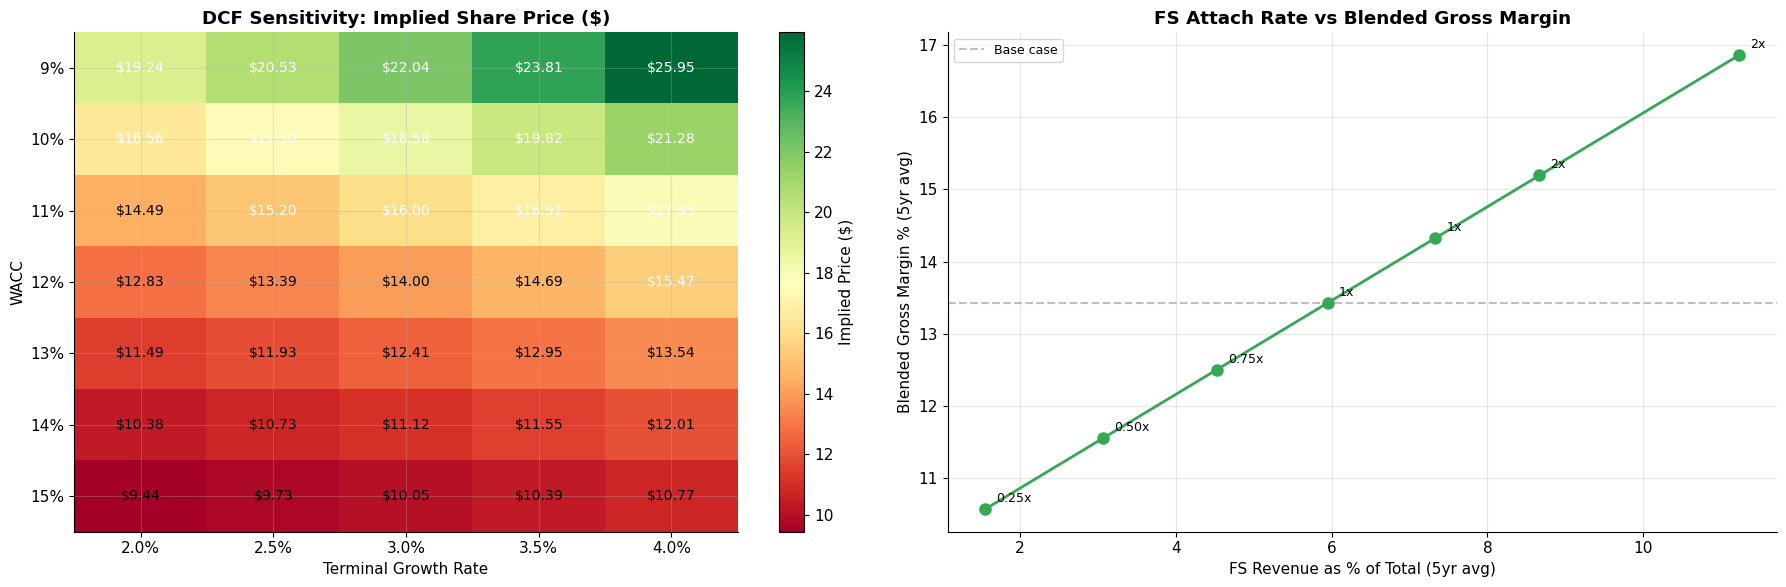


  SENSITIVITY: FS Attach Rate Multiplier → Blended GM

    Multiplier   FS % of Rev   Blended GM%   GM Uplift
  --------------------------------------------------
         0.25x          1.6%         10.6%       -2.9pp
         0.50x          3.1%         11.6%       -1.9pp
         0.75x          4.5%         12.5%       -0.9pp
         1.00x          6.0%         13.4%       +0.0pp ◄ Base
         1.25x          7.3%         14.3%       +0.9pp
         1.50x          8.7%         15.2%       +1.8pp
         2.00x         11.2%         16.9%       +3.4pp


In [18]:
# ============================================================
# CELL GROUP 6: SENSITIVITY ANALYSIS
# ============================================================

# ── 1) WACC vs Terminal Growth Rate Sensitivity ──────────────

base_dcf = dcf_results['Base']
base_fcf_terminal = base_dcf['fcf_values'][-1]
net_cash = base_dcf['net_cash']
shares_diluted = base_dcf['shares_diluted']

wacc_range = [0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15]
tg_range = [0.02, 0.025, 0.03, 0.035, 0.04]

sens_data = np.zeros((len(wacc_range), len(tg_range)))
for i, w in enumerate(wacc_range):
    for j, tg in enumerate(tg_range):
        pv_fcfs = sum(fcf / (1 + w) ** (k+1) for k, fcf in enumerate(base_dcf['fcf_values']))
        tv = base_fcf_terminal * (1 + tg) / (w - tg)
        pv_tv = tv / (1 + w) ** 5
        ev = pv_fcfs + pv_tv
        eq_val = ev + net_cash
        price = eq_val / shares_diluted
        sens_data[i, j] = price

sens_df = pd.DataFrame(sens_data,
                        index=[f'{w:.0%}' for w in wacc_range],
                        columns=[f'{tg:.1%}' for tg in tg_range])
sens_df.index.name = 'WACC \\ TG'

print('=' * 50)
print('  SENSITIVITY: Implied Share Price (Diluted)')
print('  WACC vs Terminal Growth Rate')
print('=' * 50 + '\n')

styled = sens_df.applymap(lambda x: f'${x:.2f}')
print(styled.to_string())

base_w = f'{base_dcf["wacc"]:.0%}'
base_tg = f'{base_dcf["terminal_growth"]:.1%}'
print(f'\n  Base case (WACC={base_w}, TG={base_tg}): ${base_dcf["price_diluted"]:.2f}')

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
im = ax.imshow(sens_data, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(tg_range)))
ax.set_xticklabels([f'{tg:.1%}' for tg in tg_range])
ax.set_yticks(range(len(wacc_range)))
ax.set_yticklabels([f'{w:.0%}' for w in wacc_range])
ax.set_xlabel('Terminal Growth Rate')
ax.set_ylabel('WACC')
ax.set_title('DCF Sensitivity: Implied Share Price ($)', fontweight='bold')
for i in range(len(wacc_range)):
    for j in range(len(tg_range)):
        ax.text(j, i, f'${sens_data[i,j]:.2f}', ha='center', va='center', fontsize=10,
                color='white' if sens_data[i,j] > sens_data.mean() else 'black')
plt.colorbar(im, ax=ax, label='Implied Price ($)')

# ── 2) FS Attach Rate vs Blended Gross Margin Sensitivity ───
ax = axes[1]

# Vary all FS attach rates by a multiplier and compute blended GM
attach_multipliers = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
base_proj = projections['Base']

gm_by_mult = []
fs_pct_by_mult = []
for mult in attach_multipliers:
    total_gp_sum = 0
    total_rev_sum = 0
    total_fs_sum = 0
    for yr in proj_years:
        txns = base_proj.loc[yr, 'Transactions']
        brok_rev = base_proj.loc[yr, 'Brokerage_Rev']
        brok_gp = base_proj.loc[yr, 'Brokerage_GP']

        fs_rev_yr = 0
        fs_gp_yr = 0
        for seg in ['Title', 'Mortgage', 'Wallet']:
            base_attach = scenarios['Base']['fs_attach'][seg][yr]
            adj_attach = min(base_attach * mult, 1.0)
            seg_rev = txns * adj_attach * fs_rev_per_txn[seg][yr]
            seg_gp = seg_rev * (1 - fs_cogs_pct[seg])
            fs_rev_yr += seg_rev
            fs_gp_yr += seg_gp

        total_rev_sum += brok_rev + fs_rev_yr
        total_gp_sum += brok_gp + fs_gp_yr
        total_fs_sum += fs_rev_yr

    gm_by_mult.append(total_gp_sum / total_rev_sum * 100)
    fs_pct_by_mult.append(total_fs_sum / total_rev_sum * 100)

ax.plot(fs_pct_by_mult, gm_by_mult, 'o-', color=COLORS['secondary'], linewidth=2, markersize=8)
for x, y, m in zip(fs_pct_by_mult, gm_by_mult, attach_multipliers):
    label = f'{m:.0f}x' if m >= 1 else f'{m:.2f}x'
    ax.annotate(label, (x, y), textcoords="offset points", xytext=(8, 5), fontsize=9)
ax.set_xlabel('FS Revenue as % of Total (5yr avg)')
ax.set_ylabel('Blended Gross Margin % (5yr avg)')
ax.set_title('FS Attach Rate vs Blended Gross Margin', fontweight='bold')
ax.axhline(y=gm_by_mult[3], color='gray', linestyle='--', alpha=0.5, label='Base case')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print sensitivity table
print('\n' + '=' * 60)
print('  SENSITIVITY: FS Attach Rate Multiplier → Blended GM')
print('=' * 60 + '\n')
print(f'  {"Multiplier":>12}  {"FS % of Rev":>12}  {"Blended GM%":>12}  {"GM Uplift":>10}')
print(f'  {"-"*50}')
base_gm = gm_by_mult[attach_multipliers.index(1.0)]
for mult, fs_pct, gm in zip(attach_multipliers, fs_pct_by_mult, gm_by_mult):
    uplift = gm - base_gm
    label = f'{mult:.2f}x'
    marker = ' ◄ Base' if mult == 1.0 else ''
    print(f'  {label:>12}  {fs_pct:>11.1f}%  {gm:>11.1f}%  {uplift:>+9.1f}pp{marker}')

In [19]:
# ── 2) Scenario Summary & Peer Comparison ────────────────────

print('=' * 50)
print('  SCENARIO SUMMARY')
print('=' * 50 + '\n')

scenario_summary = []
for name in ['Bull', 'Base', 'Bear']:
    d = dcf_results[name]
    is_df = three_stmt[name][0]
    proj = projections[name]
    
    rev_2030 = is_df.loc[2030, 'Revenue'] / 1e6  # $B
    ebitda_2030 = is_df.loc[2030, 'Adj_EBITDA'] / 1e3  # $M
    agents_2030 = proj.loc[2030, 'Agents']
    rev_cagr = (is_df.loc[2030, 'Revenue'] / 1_968_416) ** (1/5) - 1
    ebitda_margin = is_df.loc[2030, 'Adj_EBITDA'] / is_df.loc[2030, 'Revenue'] * 100
    ev_ebitda = d['enterprise_value'] / (ebitda_2030 * 1000)
    
    scenario_summary.append({
        'Scenario': name,
        'Price (Diluted)': f'${d["price_diluted"]:.2f}',
        'EV ($M)': f'${d["enterprise_value"]/1000:,.0f}',
        '2030 Rev ($B)': f'${rev_2030:.2f}',
        '2030 EBITDA ($M)': f'${ebitda_2030:,.0f}',
        '2030 EBITDA Margin': f'{ebitda_margin:.1f}%',
        '2030 Agents': f'{agents_2030:,}',
        'Rev CAGR 25-30': f'{rev_cagr:.1%}',
        'EV/EBITDA': f'{ev_ebitda:.1f}x',
    })

scenario_df = pd.DataFrame(scenario_summary).set_index('Scenario')
print(scenario_df.to_string())

# Peer Comparison
print('\n\n' + '=' * 50)
print('  PEER COMPARISON (approximate LTM multiples)')
print('=' * 50 + '\n')

peers = pd.DataFrame({
    'Company': ['REAX (Actual)', 'REAX (Model)', 'COMP', 'EXPI', 'FTHM', 'DOUG', 'HOUS', 'RMAX'],
    'Type': ['Tech-enabled', 'Tech-enabled', 'Tech-enabled', 'Cloud', 'Cloud', 'Traditional', 'Tech-enabled', 'Franchise'],
    'LTM Rev ($B)': ['$2.0', '-', '$2.1', '$4.6', '$0.4', '$1.6', '$6.5', '$0.6'],
    'Rev Growth': ['56%', '-', '24%', '5%', '33%', '7%', '5%', '-6%'],
    'Agent Count': ['31.7K', '-', '~55K', '~87K', '~20K', '~45K', '~55K', '~14K'],
    'EV/Rev': ['~0.8x', f'{dcf_results["Base"]["enterprise_value"]/(1968416):.1f}x', '~0.5x', '~0.3x', '~0.9x', '~0.2x', '~0.1x', '~1.5x'],
    'EV/EBITDA': ['~20x', f'{dcf_results["Base"]["enterprise_value"]/(62900):.0f}x', '~12x', '~8x', '~25x', '~8x', '~6x', '~10x'],
})
print(peers.to_string(index=False))

print('\nNote: Peer multiples are approximate and based on publicly available data.')
print('REAX trades at a premium to traditional brokerages reflecting higher growth.')

  SCENARIO SUMMARY

         Price (Diluted) EV ($M) 2030 Rev ($B) 2030 EBITDA ($M) 2030 EBITDA Margin 2030 Agents Rev CAGR 25-30 EV/EBITDA
Scenario                                                                                                               
Bull              $23.20  $5,488         $7.15             $862              12.1%      81,334          29.4%      6.4x
Base              $14.00  $3,293         $5.23             $498               9.5%      65,904          21.6%      6.6x
Bear               $7.02  $1,625         $3.52             $221               6.3%      51,475          12.3%      7.3x


  PEER COMPARISON (approximate LTM multiples)

      Company         Type LTM Rev ($B) Rev Growth Agent Count EV/Rev EV/EBITDA
REAX (Actual) Tech-enabled         $2.0        56%       31.7K  ~0.8x      ~20x
 REAX (Model) Tech-enabled            -          -           -   1.7x       52x
         COMP Tech-enabled         $2.1        24%        ~55K  ~0.5x      ~12x
         EX

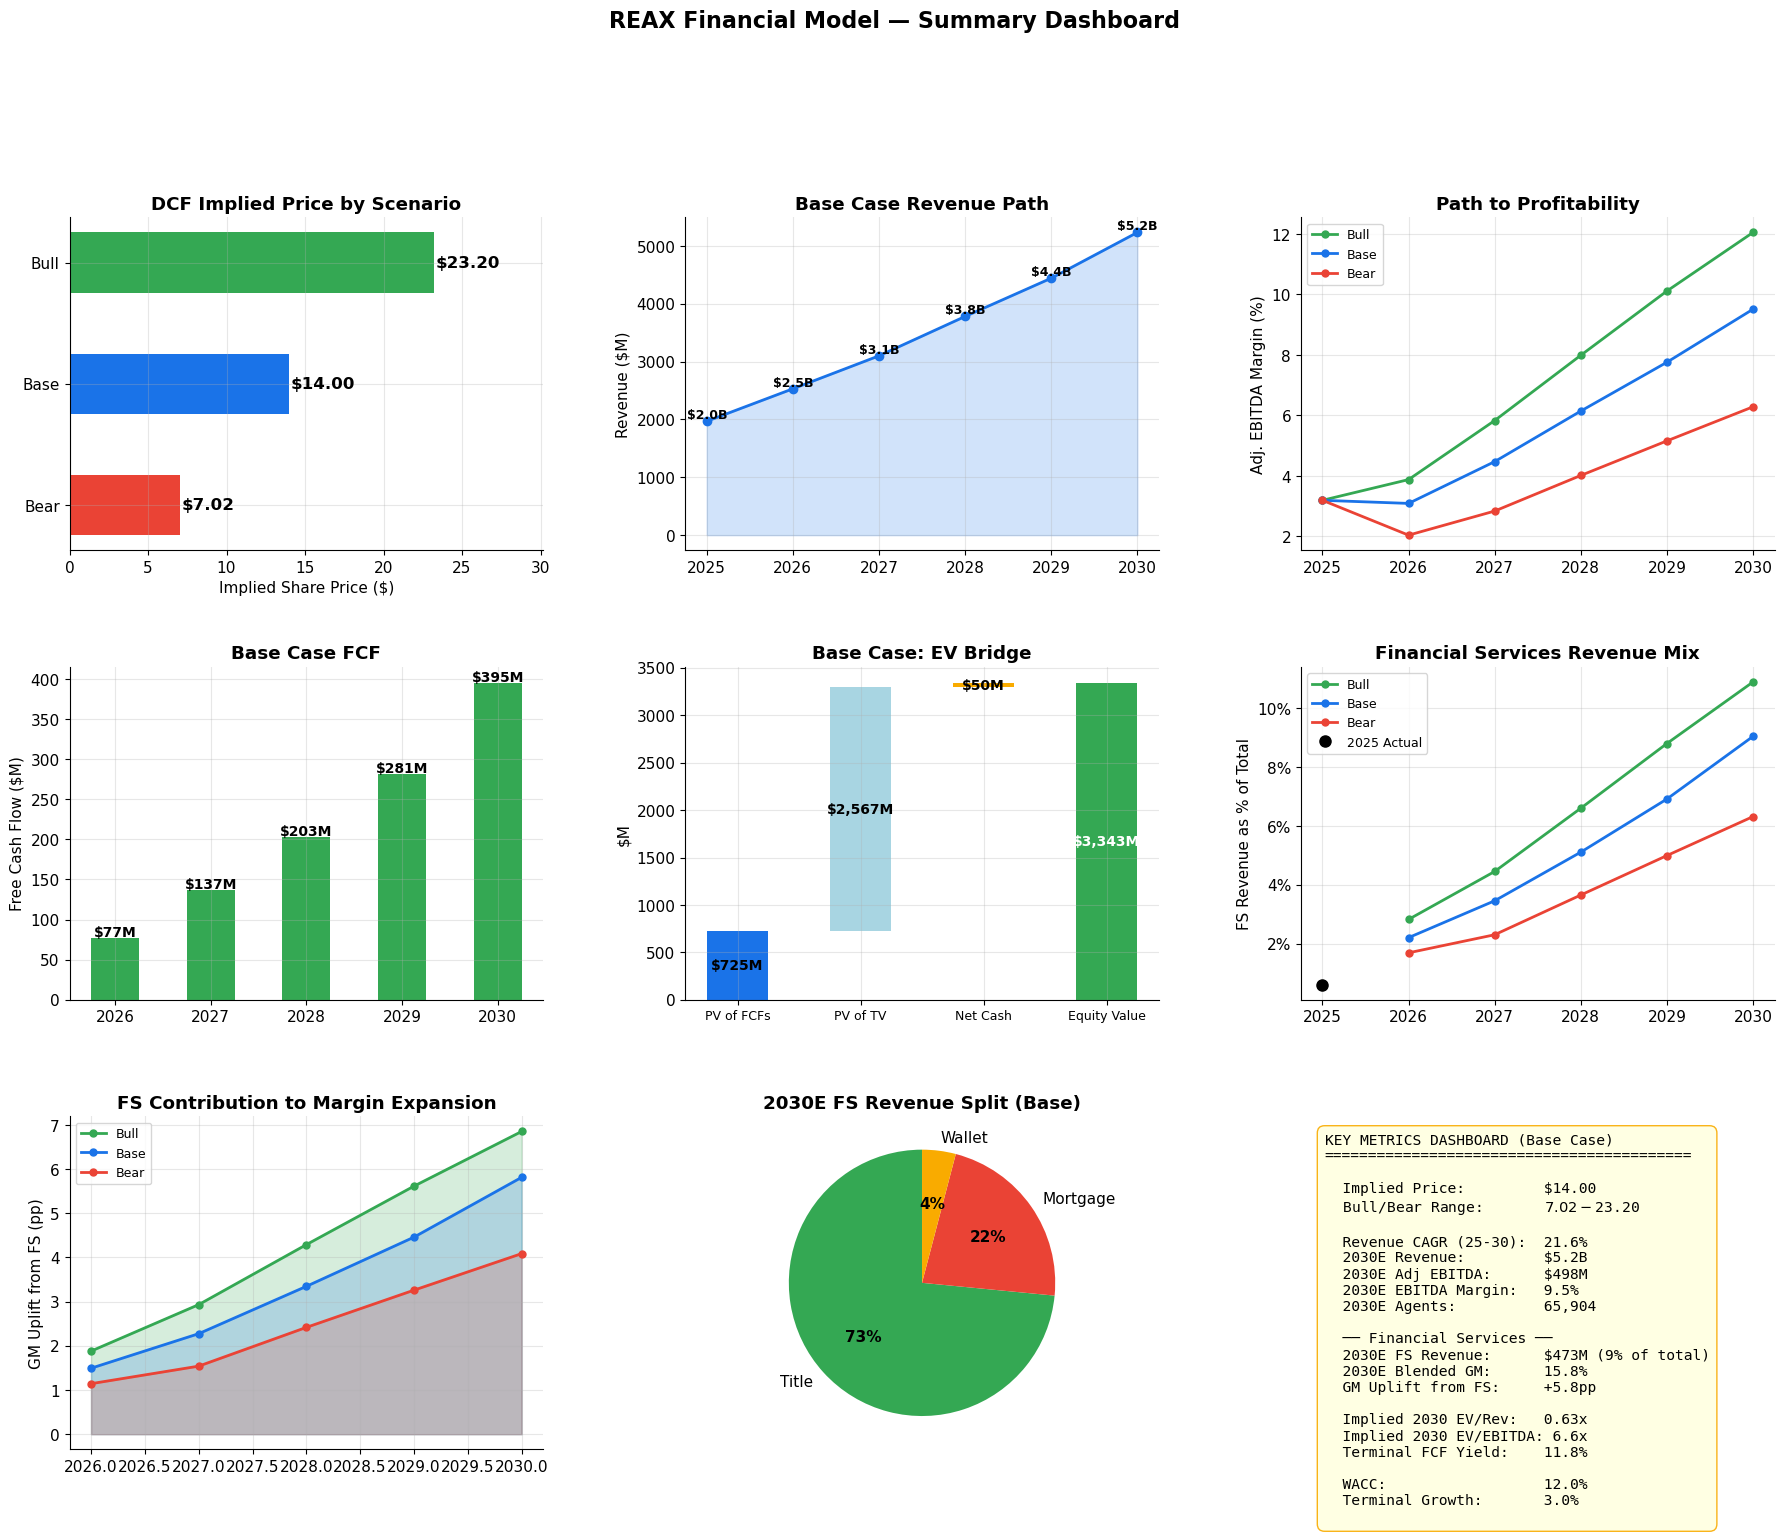


Model complete. All cells executed successfully.


In [20]:
# ── 3) Key Metrics Dashboard & Final Output ──────────────────

fig = plt.figure(figsize=(22, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
scenario_colors = {'Bull': COLORS['secondary'], 'Base': COLORS['primary'], 'Bear': COLORS['accent']}

# 1) Scenario price comparison
ax = fig.add_subplot(gs[0, 0])
names = ['Bear', 'Base', 'Bull']
prices = [dcf_results[n]['price_diluted'] for n in names]
colors_bar = [scenario_colors[n] for n in names]
bars = ax.barh(names, prices, color=colors_bar, height=0.5)
for bar, p in zip(bars, prices):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'${p:.2f}', va='center', fontweight='bold', fontsize=12)
ax.set_xlabel('Implied Share Price ($)')
ax.set_title('DCF Implied Price by Scenario', fontweight='bold')
ax.set_xlim(0, max(prices) * 1.3)

# 2) Revenue bridge
ax = fig.add_subplot(gs[0, 1])
yrs_path = [2025] + proj_years
rev_path = [1968.4] + [projections['Base'].loc[yr, 'Total_Revenue'] / 1000 for yr in proj_years]
ax.fill_between(range(len(yrs_path)), rev_path, alpha=0.2, color=COLORS['primary'])
ax.plot(range(len(yrs_path)), rev_path, 'o-', color=COLORS['primary'], linewidth=2, markersize=6)
for i, (y, r) in enumerate(zip(yrs_path, rev_path)):
    ax.text(i, r + 50, f'${r/1000:.1f}B', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(range(len(yrs_path)))
ax.set_xticklabels(yrs_path)
ax.set_ylabel('Revenue ($M)')
ax.set_title('Base Case Revenue Path', fontweight='bold')

# 3) EBITDA margin expansion
ax = fig.add_subplot(gs[0, 2])
for name in ['Bull', 'Base', 'Bear']:
    is_df = three_stmt[name][0]
    margins = [is_df.loc[yr, 'Adj_EBITDA'] / is_df.loc[yr, 'Revenue'] * 100 for yr in proj_years]
    all_margins = [62.9/1968.4*100] + margins
    ax.plot(range(len(yrs_path)), all_margins, 'o-', color=scenario_colors[name],
            linewidth=2, markersize=5, label=name)
ax.set_xticks(range(len(yrs_path)))
ax.set_xticklabels(yrs_path)
ax.set_ylabel('Adj. EBITDA Margin (%)')
ax.set_title('Path to Profitability', fontweight='bold')
ax.legend(fontsize=9)

# 4) FCF
ax = fig.add_subplot(gs[1, 0])
fcf_vals = [f/1000 for f in dcf_results['Base']['fcf_values']]
ax.bar(range(len(proj_years)), fcf_vals, color=COLORS['secondary'], width=0.5)
for i, f in enumerate(fcf_vals):
    ax.text(i, f + 2, f'${f:.0f}M', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(proj_years)))
ax.set_xticklabels(proj_years)
ax.set_ylabel('Free Cash Flow ($M)')
ax.set_title('Base Case FCF', fontweight='bold')

# 5) EV composition
ax = fig.add_subplot(gs[1, 1])
d = dcf_results['Base']
pv_fcf_total = sum(d['pv_fcfs']) / 1000
pv_tv = d['pv_terminal'] / 1000
nc = d['net_cash'] / 1000
eq = d['equity_value'] / 1000

categories = ['PV of FCFs', 'PV of TV', 'Net Cash', 'Equity Value']
values = [pv_fcf_total, pv_tv, nc, eq]
bottoms = [0, pv_fcf_total, pv_fcf_total + pv_tv, 0]
colors_wf = [COLORS['primary'], COLORS['light'], COLORS['gold'], COLORS['secondary']]

for i, (cat, val, bot, col) in enumerate(zip(categories, values, bottoms, colors_wf)):
    if i < 3:
        ax.bar(i, val, bottom=bot, color=col, width=0.5)
        ax.text(i, bot + val/2, f'${val:,.0f}M', ha='center', va='center', fontsize=10, fontweight='bold')
    else:
        ax.bar(i, val, color=col, width=0.5)
        ax.text(i, val/2, f'${val:,.0f}M', ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=9)
ax.set_ylabel('$M')
ax.set_title('Base Case: EV Bridge', fontweight='bold')

# 6) FS Revenue % of Total + Margin Contribution
ax = fig.add_subplot(gs[1, 2])
for name in ['Bull', 'Base', 'Bear']:
    proj = projections[name]
    fs_pcts = [proj.loc[yr, 'FS_Revenue'] / proj.loc[yr, 'Total_Revenue'] * 100 for yr in proj_years]
    ax.plot(proj_years, fs_pcts, 'o-', color=scenario_colors[name], linewidth=2, markersize=5, label=name)
# Add 2025 actual
fs_2025_pct = (5_035 + 6_009 + 889) / 1_968_416 * 100
ax.plot(2025, fs_2025_pct, 'ko', markersize=8, label='2025 Actual')
ax.set_ylabel('FS Revenue as % of Total')
ax.set_title('Financial Services Revenue Mix', fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# 7) Blended GM improvement from FS mix shift
ax = fig.add_subplot(gs[2, 0])
for name in ['Bull', 'Base', 'Bear']:
    proj = projections[name]
    blended_gm = [proj.loc[yr, 'Gross_Margin_Pct'] for yr in proj_years]
    brok_gm = [proj.loc[yr, 'Brokerage_GM_Pct'] for yr in proj_years]
    gm_uplift = [b - k for b, k in zip(blended_gm, brok_gm)]
    ax.fill_between(proj_years, 0, gm_uplift, alpha=0.2, color=scenario_colors[name])
    ax.plot(proj_years, gm_uplift, 'o-', color=scenario_colors[name], linewidth=2, markersize=5, label=name)
ax.set_ylabel('GM Uplift from FS (pp)')
ax.set_title('FS Contribution to Margin Expansion', fontweight='bold')
ax.legend(fontsize=9)

# 8) FS Segment Breakdown (Base, 2030)
ax = fig.add_subplot(gs[2, 1])
base_2030 = projections['Base'].loc[2030]
fs_segments = ['Title', 'Mortgage', 'Wallet']
fs_revs = [base_2030[f'{s}_Rev'] / 1e3 for s in fs_segments]
fs_colors = [COLORS['secondary'], COLORS['accent'], COLORS['gold']]
wedges, texts, autotexts = ax.pie(fs_revs, labels=fs_segments, colors=fs_colors, autopct='%1.0f%%',
                                   startangle=90, textprops={'fontsize': 11})
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('2030E FS Revenue Split (Base)', fontweight='bold')

# 9) Key metrics summary
ax = fig.add_subplot(gs[2, 2])
ax.axis('off')
base_is = three_stmt['Base'][0]
rev_cagr_5y = (base_is.loc[2030, 'Revenue'] / 1_968_416) ** (1/5) - 1
ebitda_2030 = base_is.loc[2030, 'Adj_EBITDA'] / 1000
ebitda_margin_2030 = base_is.loc[2030, 'Adj_EBITDA'] / base_is.loc[2030, 'Revenue'] * 100
fcf_yield = dcf_results['Base']['fcf_values'][-1] / dcf_results['Base']['equity_value'] * 100
agents_2030 = projections['Base'].loc[2030, 'Agents']
ev_rev = dcf_results['Base']['enterprise_value'] / base_is.loc[2030, 'Revenue']
ev_ebitda = dcf_results['Base']['enterprise_value'] / base_is.loc[2030, 'Adj_EBITDA']
fs_rev_2030 = projections['Base'].loc[2030, 'FS_Revenue'] / 1e3
fs_pct_2030 = projections['Base'].loc[2030, 'FS_Revenue'] / projections['Base'].loc[2030, 'Total_Revenue'] * 100
blended_gm_2030 = projections['Base'].loc[2030, 'Gross_Margin_Pct']

metrics_text = (
    f"KEY METRICS DASHBOARD (Base Case)\n"
    f"{'=' * 42}\n\n"
    f"  Implied Price:         ${dcf_results['Base']['price_diluted']:.2f}\n"
    f"  Bull/Bear Range:       ${dcf_results['Bear']['price_diluted']:.2f} - ${dcf_results['Bull']['price_diluted']:.2f}\n\n"
    f"  Revenue CAGR (25-30):  {rev_cagr_5y:.1%}\n"
    f"  2030E Revenue:         ${base_is.loc[2030, 'Revenue']/1e6:.1f}B\n"
    f"  2030E Adj EBITDA:      ${ebitda_2030:,.0f}M\n"
    f"  2030E EBITDA Margin:   {ebitda_margin_2030:.1f}%\n"
    f"  2030E Agents:          {agents_2030:,}\n\n"
    f"  ── Financial Services ──\n"
    f"  2030E FS Revenue:      ${fs_rev_2030:,.0f}M ({fs_pct_2030:.0f}% of total)\n"
    f"  2030E Blended GM:      {blended_gm_2030:.1f}%\n"
    f"  GM Uplift from FS:     +{blended_gm_2030 - projections['Base'].loc[2030, 'Brokerage_GM_Pct']:.1f}pp\n\n"
    f"  Implied 2030 EV/Rev:   {ev_rev:.2f}x\n"
    f"  Implied 2030 EV/EBITDA: {ev_ebitda:.1f}x\n"
    f"  Terminal FCF Yield:    {fcf_yield:.1f}%\n\n"
    f"  WACC:                  {dcf_results['Base']['wacc']:.1%}\n"
    f"  Terminal Growth:       3.0%\n"
)
ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=10.5,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor=COLORS['gold'], alpha=0.9))

plt.suptitle('REAX Financial Model — Summary Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.show()

print('\nModel complete. All cells executed successfully.')